# One-phase Euler coordinates for affine Brownian factors

This notebook is the reproducible computational record for the research question

\[ Z_t=Z_0+a t+bW_t Z_0r(\_t)e^{i\_t}, \]

with a deterministic, time-independent radius and a single lossless stochastic phase.

The notebook does four things:

1.  verifies the exact affine-line theorem and its formulas;
2.  tests the nonlinear phase SDE against its transformed-Gaussian law;
3.  compares secant, Cayley, spiral, and moving-line candidates;
4.  tests claims about vector geometry, complex derivatives, PDE compactification, SDE numerics, and Monte Carlo.

Numerical evidence illustrates and stress-tests the proofs in the accompanying Markdown documents. It does not replace those proofs.

## 1. Assumptions, environment, and deterministic evidence helpers

Throughout, (W) is a real standard Brownian motion. The notation ((dW)^2=dt) refers to quadratic variation, not to a finite-increment identity and not to (i^2=-1).

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import scipy
from scipy import sparse, stats
from scipy.integrate import quad
from scipy.sparse.linalg import expm_multiply

ROOT = Path.cwd().resolve()
if not (ROOT / "phase5_model.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(path for path in candidates if (path / "phase5_model.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from phase5_model import (
    AffinePhaseParameters,
    affine_exact_phase_step,
    affine_forward,
    affine_phase,
    affine_phase_coefficients,
    affine_radius,
    affine_scalar_from_phase,
    affine_transition_density,
    canonical_embedding,
    canonical_exact_phase_step,
    canonical_inverse,
    canonical_phase,
    canonical_phase_coefficients,
    canonical_phase_density,
    canonical_radius,
    cayley_complex_coefficients,
    cayley_exact_phase_step,
    cayley_inverse,
    cayley_phase,
    cayley_phase_coefficients,
    cayley_transform,
    moving_line_phase,
    moving_line_radius,
    moving_line_state,
    phase_noise_covariance,
    spiral_phase,
    spiral_radius,
    spiral_state,
    transported_add,
    cayley_transported_add,
)
from phase5_finance import (
    bachelier_call_delta,
    bachelier_call_gamma,
    bachelier_call_price,
    phase_bachelier_call_price,
    scalar_delta_from_phase,
    scalar_gamma_from_phase,
)

BASE_SEED = 20260725
SECOND_SEED = 20360725
# SciPy's sparse matrix-exponential norm estimator still uses the
# legacy NumPy RNG internally. Seed it explicitly in addition to the
# independent Generator streams used by every Monte Carlo experiment.
np.random.seed(BASE_SEED)
PAPER = ROOT / "paper" / "one-phase-euler"
EVIDENCE = PAPER / "tables"
RASTER = PAPER / "figures" / "raster"
VECTOR = PAPER / "figures" / "vector"
for directory in (EVIDENCE, RASTER, VECTOR):
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (9.2, 5.6),
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.frameon": False,
    }
)

def save_figure(fig, name):
    fig.tight_layout()
    fig.savefig(RASTER / f"{name}.png", bbox_inches="tight")
    fig.savefig(VECTOR / f"{name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_table(frame, name):
    frame.to_csv(EVIDENCE / name, index=False, float_format="%.12g")
    return frame

def save_json(payload, name):
    (EVIDENCE / name).write_text(
        json.dumps(payload, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    return payload

versions = pd.DataFrame(
    [
        ("python", platform.python_version()),
        ("numpy", np.__version__),
        ("scipy", scipy.__version__),
        ("pandas", pd.__version__),
        ("matplotlib", matplotlib.__version__),
        ("nbformat", nbformat.__version__),
        ("base_seed", str(BASE_SEED)),
        ("second_seed", str(SECOND_SEED)),
    ],
    columns=["component", "version"],
)
save_table(versions, "software_versions.csv")
versions

## 2. Candidate comparison

“Exact representation” and “invertible transformation” are kept separate. The Cayley variable is on the unit circle, but it is not the original additive complex state.

In [2]:
candidate_rows = [
    (
        "canonical secant",
        "original affine embedding",
        True,
        True,
        "open interval of length pi",
        False,
        "exact transformed Gaussian",
    ),
    (
        "general affine line",
        "original eligible affine state",
        True,
        True,
        "open interval of length pi",
        False,
        "exact transformed Gaussian",
    ),
    (
        "Cayley",
        "invertible transform",
        True,
        True,
        "(-pi, pi)",
        False,
        "exact transformed Gaussian",
    ),
    (
        "wrapped exponential",
        "encoding only",
        True,
        False,
        "circle",
        True,
        "loses winding index",
    ),
    (
        "compatible logarithmic spiral",
        "multiplicative state",
        True,
        True,
        "real line",
        True,
        "exact affine Gaussian phase",
    ),
    (
        "moving affine line",
        "original general affine state",
        False,
        True,
        "time-dependent half-turn",
        False,
        "fails at support origin crossing",
    ),
]
candidates = pd.DataFrame(
    candidate_rows,
    columns=[
        "candidate",
        "represents",
        "time_independent_radius",
        "lossless",
        "phase_domain",
        "can_wind",
        "transition_or_limit",
    ],
)
save_table(candidates, "candidate_comparison.csv")
candidates

## 3. Canonical secant geometry

For (Y_t=t+W_t),

\[ \_t=(Y_t/c),+iY_t/c=\_t,e^{i\_t}. \]

The phase is genuine and lossless, but the image is a vertical line and the phase never leaves one half-turn.

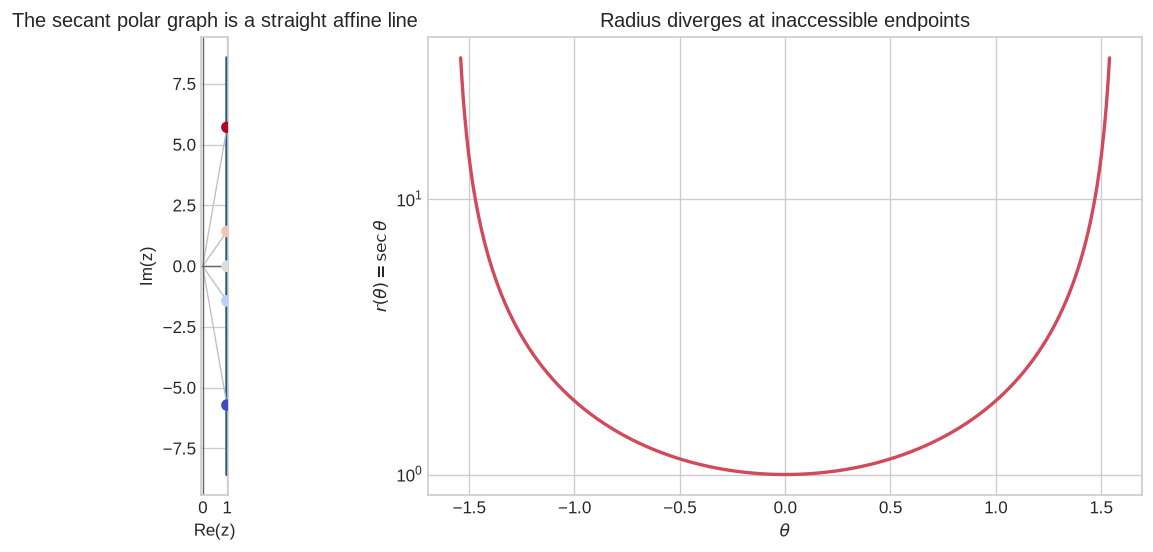

In [3]:
c = 1.4
y_grid = np.linspace(-12.0, 12.0, 2001)
theta_grid = canonical_phase(y_grid, c)
z_grid = canonical_embedding(theta_grid)
reconstruction = canonical_inverse(theta_grid, c)
identity_error = np.max(np.abs(z_grid - (1.0 + 1j * y_grid / c)))
inverse_error = np.max(np.abs(reconstruction - y_grid))

secant_evidence = pd.DataFrame(
    [
        ("Euler identity max error", identity_error),
        ("inverse max error", inverse_error),
        ("observed phase span", theta_grid.max() - theta_grid.min()),
        ("limiting phase span", np.pi),
    ],
    columns=["metric", "value"],
)
save_table(secant_evidence, "secant_reconstruction.csv")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.7))
axes[0].plot(z_grid.real, z_grid.imag, color="#235789", lw=2)
selected = np.array([-8.0, -2.0, 0.0, 2.0, 8.0])
z_selected = 1.0 + 1j * selected / c
axes[0].scatter(z_selected.real, z_selected.imag, c=selected, cmap="coolwarm", zorder=3)
for point in z_selected:
    axes[0].plot([0.0, point.real], [0.0, point.imag], color="0.75", lw=0.8)
axes[0].axhline(0.0, color="0.4", lw=0.8)
axes[0].axvline(0.0, color="0.4", lw=0.8)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("The secant polar graph is a straight affine line")
axes[0].set_xlabel("Re(z)")
axes[0].set_ylabel("Im(z)")

angular = np.linspace(-1.54, 1.54, 1000)
axes[1].plot(angular, canonical_radius(angular), color="#d1495b", lw=2)
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_ylabel(r"$r(\theta)=\sec\theta$")
axes[1].set_title("Radius diverges at inaccessible endpoints")
save_figure(fig, "f01_secant_geometry")
secant_evidence

## 4. General oblique affine lines

Eligibility requires (a/bR) and (b/Z_0R). Writing (b/Z_0=e^{i}),

\[ r()=, x()=. \]

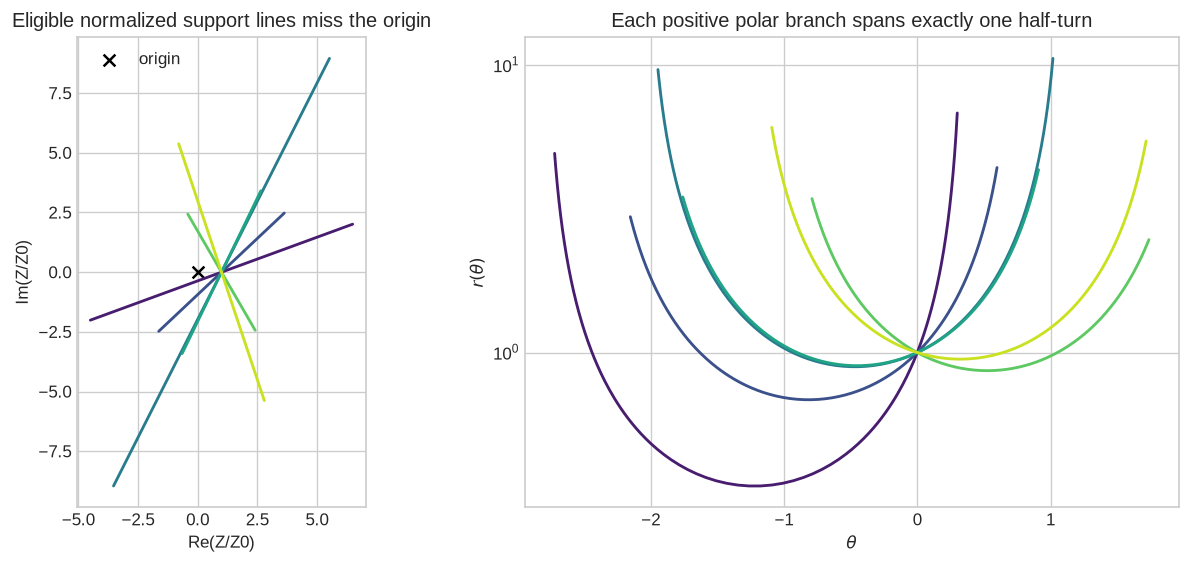

In [4]:
rng_affine = np.random.default_rng(BASE_SEED + 1)
affine_records = []
affine_examples = []
for index in range(6):
    z0 = rng_affine.normal() + 1j * rng_affine.normal()
    if abs(z0) < 0.3:
        z0 += 1.0
    while True:
        b = rng_affine.normal() + 1j * rng_affine.normal()
        if abs(b) > 0.3 and abs((b / z0).imag) > 0.15:
            break
    lam = rng_affine.uniform(-1.0, 1.0)
    params = AffinePhaseParameters(z0=z0, a=lam * b, b=b)
    x = rng_affine.normal(size=4000) * 4.0
    theta = affine_phase(x, params)
    reconstructed_x = affine_scalar_from_phase(theta, params)
    represented = affine_forward(theta, params)
    direct = z0 + b * x
    affine_records.append(
        {
            "case": index,
            "lambda": lam,
            "rho": params.rho,
            "phi": params.phi,
            "phase_span_limit": params.phase_interval[1] - params.phase_interval[0],
            "max_scalar_error": np.max(np.abs(reconstructed_x - x)),
            "max_complex_error": np.max(np.abs(represented - direct)),
        }
    )
    affine_examples.append((params, np.linspace(-5.0, 5.0, 400)))

affine_evidence = save_table(
    pd.DataFrame(affine_records),
    "general_affine_reconstruction.csv",
)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(affine_examples)))
for color, (params, x) in zip(colors, affine_examples):
    theta = affine_phase(x, params)
    normalized = affine_forward(theta, params) / params.z0
    axes[0].plot(normalized.real, normalized.imag, color=color, lw=1.7)
    axes[1].plot(theta, affine_radius(theta, params), color=color, lw=1.7)
axes[0].scatter([0.0], [0.0], marker="x", color="black", s=50, label="origin")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Eligible normalized support lines miss the origin")
axes[0].set_xlabel("Re(Z/Z0)")
axes[0].set_ylabel("Im(Z/Z0)")
axes[0].legend()
axes[1].set_yscale("log")
axes[1].set_title("Each positive polar branch spans exactly one half-turn")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_ylabel(r"$r(\theta)$")
save_figure(fig, "f02_general_affine_geometry")
affine_evidence

## 5. Why radial and noncollinear affine processes fail

A radial line supplies only two geometric directions, so a genuine phase cannot recover its continuum of radii. With noncollinear drift and diffusion, randomizing time gives a planar density; a Borel polar graph has planar measure zero.

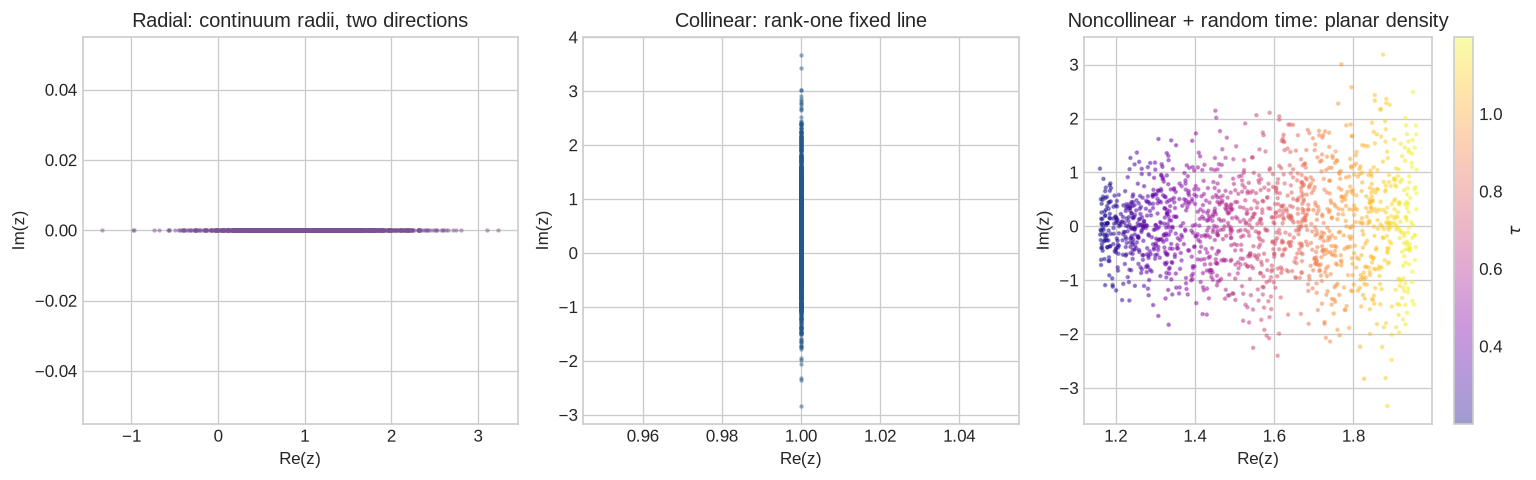

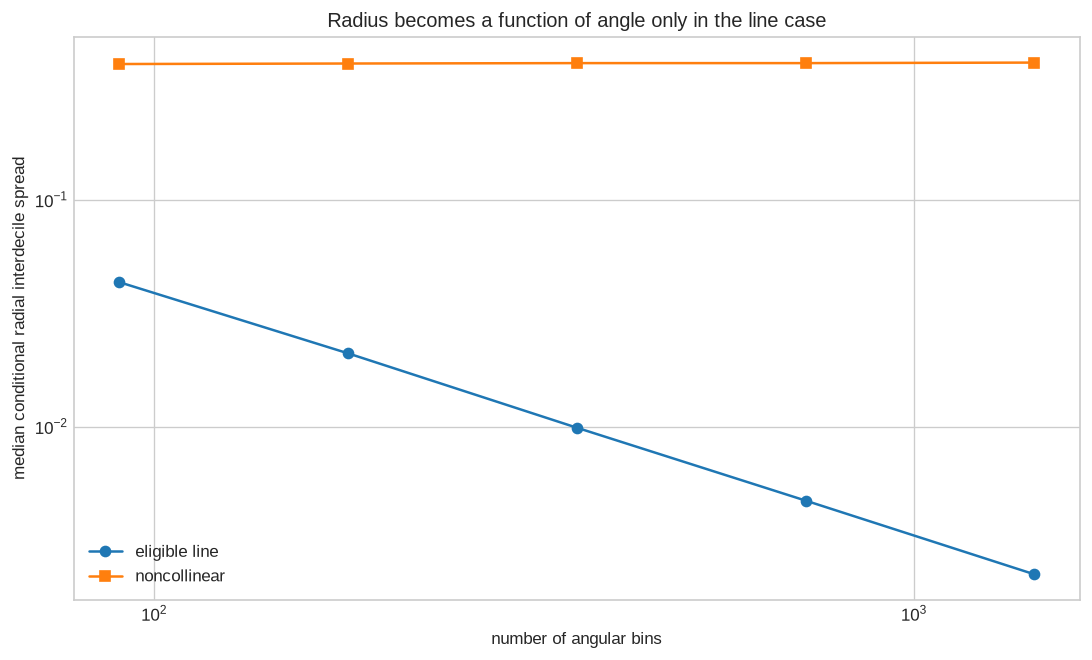

(                       case  eigenvalue_1  eigenvalue_2  determinant  \
 0               radial line      0.000000      0.341113     0.000000   
 1   eligible collinear line      0.000000      0.712960     0.000000   
 2  random-time noncollinear      0.053084      0.696150     0.036954   
 
    empirical_rank_tol_1e-8  
 0                        1  
 1                        1  
 2                        2  ,
    angle_bins  eligible_collinear  noncollinear
 0          90            0.043356      0.395882
 1         180            0.021075      0.397920
 2         360            0.009918      0.399551
 3         720            0.004738      0.399511
 4        1440            0.002245      0.401697)

In [5]:
rng_support = np.random.default_rng(BASE_SEED + 2)
n_support = 120_000
tau = rng_support.uniform(0.2, 1.2, size=n_support)
gaussian = rng_support.normal(size=n_support)
w_tau = np.sqrt(tau) * gaussian

z_collinear = 1.0 + 1j * (0.45 * tau + w_tau)
z_noncollinear = 1.0 + 0.8 * tau + 1j * w_tau
radial = 1.0 + 0.7 * w_tau

def real_covariance(z):
    return np.cov(np.column_stack([z.real, z.imag]), rowvar=False)

support_rows = []
for name, values in [
    ("radial line", radial.astype(complex)),
    ("eligible collinear line", z_collinear),
    ("random-time noncollinear", z_noncollinear),
]:
    covariance = real_covariance(values)
    eigenvalues = np.linalg.eigvalsh(covariance)
    support_rows.append(
        {
            "case": name,
            "eigenvalue_1": eigenvalues[0],
            "eigenvalue_2": eigenvalues[1],
            "determinant": np.linalg.det(covariance),
            "empirical_rank_tol_1e-8": np.linalg.matrix_rank(covariance, tol=1e-8),
        }
    )
support_dimension = save_table(
    pd.DataFrame(support_rows),
    "support_dimension.csv",
)

def angle_bin_radius_spread(z, bins):
    angle = np.angle(z)
    radius = np.abs(z)
    indices = np.floor((angle + np.pi) * bins / (2.0 * np.pi)).astype(int)
    indices = np.clip(indices, 0, bins - 1)
    frame = pd.DataFrame({"bin": indices, "radius": radius})
    grouped = frame.groupby("bin")["radius"]
    summary = grouped.agg(["count", "median", lambda x: x.quantile(0.9), lambda x: x.quantile(0.1)])
    summary.columns = ["count", "median", "q90", "q10"]
    summary = summary[summary["count"] >= 40]
    return float(np.median((summary["q90"] - summary["q10"]) / summary["median"]))

spread_rows = []
for bins in (90, 180, 360, 720, 1440):
    spread_rows.append(
        {
            "angle_bins": bins,
            "eligible_collinear": angle_bin_radius_spread(z_collinear, bins),
            "noncollinear": angle_bin_radius_spread(z_noncollinear, bins),
        }
    )
angle_spread = save_table(pd.DataFrame(spread_rows), "angle_bin_spread.csv")

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.1))
subset = slice(None, None, 80)
axes[0].scatter(radial[subset], np.zeros_like(radial[subset]), s=3, alpha=0.35, color="#7a5195")
axes[0].set_title("Radial: continuum radii, two directions")
axes[0].set_xlabel("Re(z)")
axes[0].set_ylabel("Im(z)")
axes[1].scatter(z_collinear.real[subset], z_collinear.imag[subset], s=3, alpha=0.35, color="#235789")
axes[1].set_title("Collinear: rank-one fixed line")
axes[1].set_xlabel("Re(z)")
axes[1].set_ylabel("Im(z)")
scatter = axes[2].scatter(
    z_noncollinear.real[subset],
    z_noncollinear.imag[subset],
    c=tau[subset],
    s=3,
    alpha=0.4,
    cmap="plasma",
)
axes[2].set_title("Noncollinear + random time: planar density")
axes[2].set_xlabel("Re(z)")
axes[2].set_ylabel("Im(z)")
fig.colorbar(scatter, ax=axes[2], label=r"$\tau$")
save_figure(fig, "f03_support_obstructions")

fig, ax = plt.subplots()
ax.loglog(angle_spread["angle_bins"], angle_spread["eligible_collinear"], "o-", label="eligible line")
ax.loglog(angle_spread["angle_bins"], angle_spread["noncollinear"], "s-", label="noncollinear")
ax.set_xlabel("number of angular bins")
ax.set_ylabel("median conditional radial interdecile spread")
ax.set_title("Radius becomes a function of angle only in the line case")
ax.legend()
save_figure(fig, "f04_angle_bin_factorization")
support_dimension, angle_spread

## 6. Nonlinear phase SDE: independent numerical verification

The exact endpoint is used only as a reference. Euler–Maruyama, Milstein, and stochastic Heun are advanced directly from the nonlinear phase coefficients on shared Brownian increments.

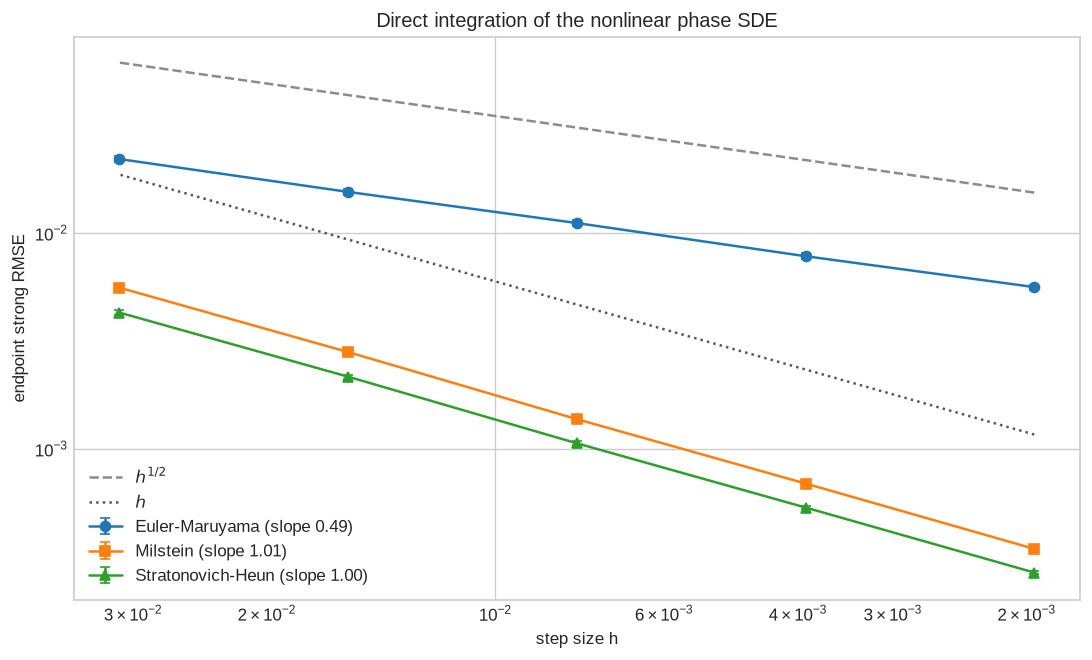

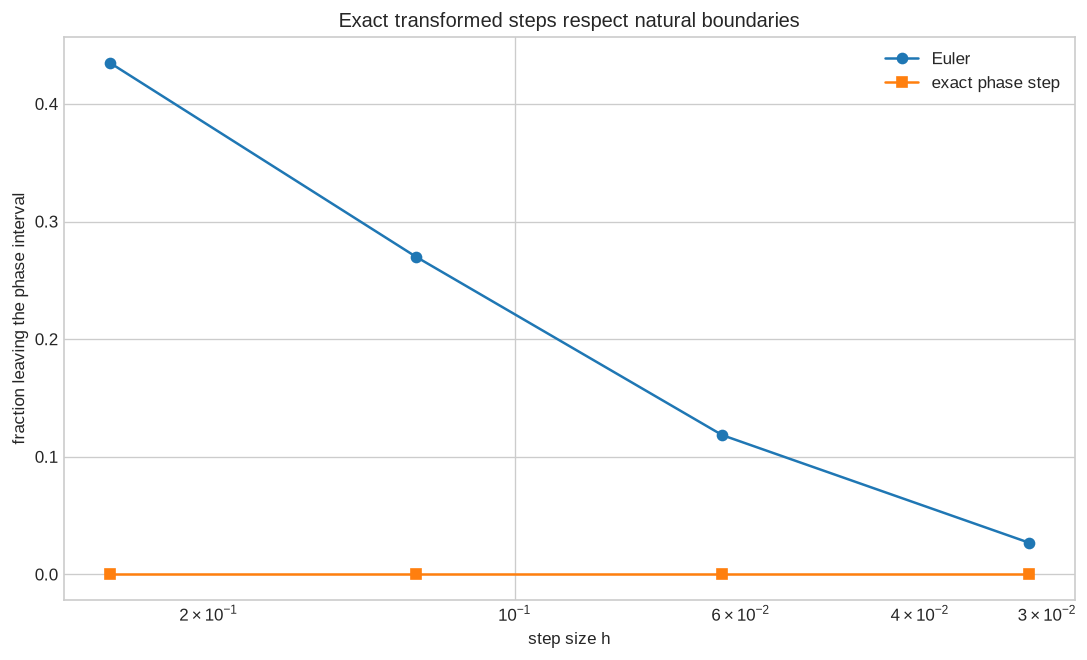

(               method  steps         h      rmse  rmse_standard_error  \
 0      Euler-Maruyama     32  0.031250  0.022114             0.000369   
 1            Milstein     32  0.031250  0.005611             0.000092   
 2   Stratonovich-Heun     32  0.031250  0.004302             0.000059   
 3      Euler-Maruyama     64  0.015625  0.015579             0.000250   
 4            Milstein     64  0.015625  0.002824             0.000039   
 5   Stratonovich-Heun     64  0.015625  0.002171             0.000026   
 6      Euler-Maruyama    128  0.007812  0.011175             0.000181   
 7            Milstein    128  0.007812  0.001381             0.000016   
 8   Stratonovich-Heun    128  0.007812  0.001067             0.000011   
 9      Euler-Maruyama    256  0.003906  0.007848             0.000120   
 10           Milstein    256  0.003906  0.000695             0.000008   
 11  Stratonovich-Heun    256  0.003906  0.000538             0.000005   
 12     Euler-Maruyama    512  0.00195

In [6]:
mu_sde, sigma_sde, c_sde, horizon = 0.3, 0.8, 1.25, 1.0
n_paths, finest_steps = 4_000, 512
rng_sde = np.random.default_rng(BASE_SEED + 3)
finest_dw = rng_sde.normal(
    scale=np.sqrt(horizon / finest_steps),
    size=(n_paths, finest_steps),
)
total_w = finest_dw.sum(axis=1)
exact_endpoint = canonical_phase(mu_sde * horizon + sigma_sde * total_w, c_sde)

def ito_ab(theta):
    return canonical_phase_coefficients(theta, mu_sde, sigma_sde, c_sde)

def strat_ab(theta):
    cosine = np.cos(theta)
    return (
        mu_sde * cosine**2 / c_sde,
        sigma_sde * cosine**2 / c_sde,
    )

def advance_phase(increments, method):
    h = horizon / increments.shape[1]
    theta = np.zeros(increments.shape[0])
    ever_outside = np.zeros(increments.shape[0], dtype=bool)
    for dw in increments.T:
        if method == "Euler-Maruyama":
            drift, diffusion = ito_ab(theta)
            theta = theta + drift * h + diffusion * dw
        elif method == "Milstein":
            drift, diffusion = ito_ab(theta)
            diffusion_prime = (
                -2.0 * sigma_sde * np.sin(theta) * np.cos(theta) / c_sde
            )
            theta = (
                theta
                + drift * h
                + diffusion * dw
                + 0.5 * diffusion * diffusion_prime * (dw**2 - h)
            )
        elif method == "Stratonovich-Heun":
            drift, diffusion = strat_ab(theta)
            predictor = theta + drift * h + diffusion * dw
            drift_p, diffusion_p = strat_ab(predictor)
            theta = (
                theta
                + 0.5 * (drift + drift_p) * h
                + 0.5 * (diffusion + diffusion_p) * dw
            )
        else:
            raise ValueError(method)
        ever_outside |= np.abs(theta) >= np.pi / 2.0
    return theta, ever_outside

convergence_rows = []
methods = ("Euler-Maruyama", "Milstein", "Stratonovich-Heun")
for steps in (32, 64, 128, 256, 512):
    block = finest_steps // steps
    increments = finest_dw.reshape(n_paths, steps, block).sum(axis=2)
    for method in methods:
        approximation, outside = advance_phase(increments, method)
        error = approximation - exact_endpoint
        squared = error**2
        rmse = np.sqrt(np.mean(squared))
        rmse_se = np.std(squared, ddof=1) / (
            2.0 * rmse * np.sqrt(n_paths)
        )
        convergence_rows.append(
            {
                "method": method,
                "steps": steps,
                "h": horizon / steps,
                "rmse": rmse,
                "rmse_standard_error": rmse_se,
                "weak_mean_error": abs(np.mean(approximation) - np.mean(exact_endpoint)),
                "boundary_violation_rate": np.mean(outside),
            }
        )
convergence = pd.DataFrame(convergence_rows)
slope_rows = []
for method in methods:
    subset_method = convergence[convergence["method"] == method]
    slope = np.polyfit(
        np.log(subset_method["h"]),
        np.log(subset_method["rmse"]),
        1,
    )[0]
    slope_rows.append({"method": method, "fitted_strong_slope": slope})
slopes = pd.DataFrame(slope_rows)
convergence = convergence.merge(slopes, on="method")
save_table(convergence, "phase_sde_convergence.csv")

# Repeat the principal convergence experiment with a disjoint seed
# family. This is an independent robustness check, not another method.
rng_sde_second = np.random.default_rng(SECOND_SEED + 3)
second_dw = rng_sde_second.normal(
    scale=np.sqrt(horizon / finest_steps),
    size=(n_paths, finest_steps),
)
second_total_w = second_dw.sum(axis=1)
second_exact = canonical_phase(
    mu_sde * horizon + sigma_sde * second_total_w,
    c_sde,
)
second_rows = []
for steps in (32, 64, 128, 256, 512):
    block = finest_steps // steps
    increments = second_dw.reshape(n_paths, steps, block).sum(axis=2)
    for method in methods:
        approximation, outside = advance_phase(increments, method)
        error = approximation - second_exact
        squared = error**2
        second_rows.append(
            {
                "method": method,
                "steps": steps,
                "h": horizon / steps,
                "rmse": np.sqrt(np.mean(squared)),
                "boundary_violation_rate": np.mean(outside),
            }
        )
second_convergence = pd.DataFrame(second_rows)
second_slope_rows = []
for method in methods:
    values = second_convergence[second_convergence["method"] == method]
    second_slope_rows.append(
        {
            "method": method,
            "fitted_strong_slope": np.polyfit(
                np.log(values["h"]),
                np.log(values["rmse"]),
                1,
            )[0],
        }
    )
second_convergence = second_convergence.merge(
    pd.DataFrame(second_slope_rows),
    on="method",
)
seed_replication_rows = []
for family, seed, values in (
    ("base", BASE_SEED, convergence),
    ("second", SECOND_SEED, second_convergence),
):
    for method in methods:
        method_values = values[values["method"] == method]
        finest = method_values[method_values["steps"] == finest_steps].iloc[0]
        seed_replication_rows.append(
            {
                "seed_family": family,
                "seed": seed,
                "method": method,
                "fitted_strong_slope": method_values[
                    "fitted_strong_slope"
                ].iloc[0],
                "finest_step_rmse": finest["rmse"],
                "maximum_boundary_violation_rate": method_values[
                    "boundary_violation_rate"
                ].max(),
            }
        )
seed_replication = save_table(
    pd.DataFrame(seed_replication_rows),
    "second_seed_replication.csv",
)

fig, ax = plt.subplots()
markers = {"Euler-Maruyama": "o", "Milstein": "s", "Stratonovich-Heun": "^"}
for method in methods:
    values = convergence[convergence["method"] == method]
    ax.errorbar(
        values["h"],
        values["rmse"],
        yerr=1.96 * values["rmse_standard_error"],
        marker=markers[method],
        capsize=3,
        label=f"{method} (slope {values['fitted_strong_slope'].iloc[0]:.2f})",
    )
reference_h = np.array([1 / 512, 1 / 32])
ax.loglog(reference_h, 0.35 * reference_h**0.5, "--", color="0.55", label=r"$h^{1/2}$")
ax.loglog(reference_h, 0.6 * reference_h, ":", color="0.35", label=r"$h$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("step size h")
ax.set_ylabel("endpoint strong RMSE")
ax.set_title("Direct integration of the nonlinear phase SDE")
ax.legend()
save_figure(fig, "f05_phase_sde_convergence")

rng_boundary = np.random.default_rng(BASE_SEED + 4)
stress_paths = 120_000
stress_normal = rng_boundary.normal(size=stress_paths)
stress_rows = []
for h in (0.25, 0.125, 0.0625, 0.03125):
    c_stress, sigma_stress = 0.25, 1.0
    exact = canonical_exact_phase_step(
        0.0, h, stress_normal, 0.0, sigma_stress, c_stress
    )
    drift0, diffusion0 = canonical_phase_coefficients(
        0.0, 0.0, sigma_stress, c_stress
    )
    euler = drift0 * h + diffusion0 * np.sqrt(h) * stress_normal
    stress_rows.append(
        {
            "h": h,
            "exact_boundary_violation_rate": np.mean(np.abs(exact) >= np.pi / 2.0),
            "euler_boundary_violation_rate": np.mean(np.abs(euler) >= np.pi / 2.0),
            "exact_max_abs_phase": np.max(np.abs(exact)),
            "euler_max_abs_phase": np.max(np.abs(euler)),
        }
    )
boundary_stress = save_table(pd.DataFrame(stress_rows), "boundary_stress.csv")

fig, ax = plt.subplots()
ax.plot(boundary_stress["h"], boundary_stress["euler_boundary_violation_rate"], "o-", label="Euler")
ax.plot(boundary_stress["h"], boundary_stress["exact_boundary_violation_rate"], "s-", label="exact phase step")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("step size h")
ax.set_ylabel("fraction leaving the phase interval")
ax.set_title("Exact transformed steps respect natural boundaries")
ax.legend()
save_figure(fig, "f06_boundary_stress")
convergence, seed_replication, boundary_stress

## 7. Transition density, semigroup, generator, and endpoint tails

The density is a Gaussian change of variables. Independent quadrature checks normalization and Chapman–Kolmogorov composition.

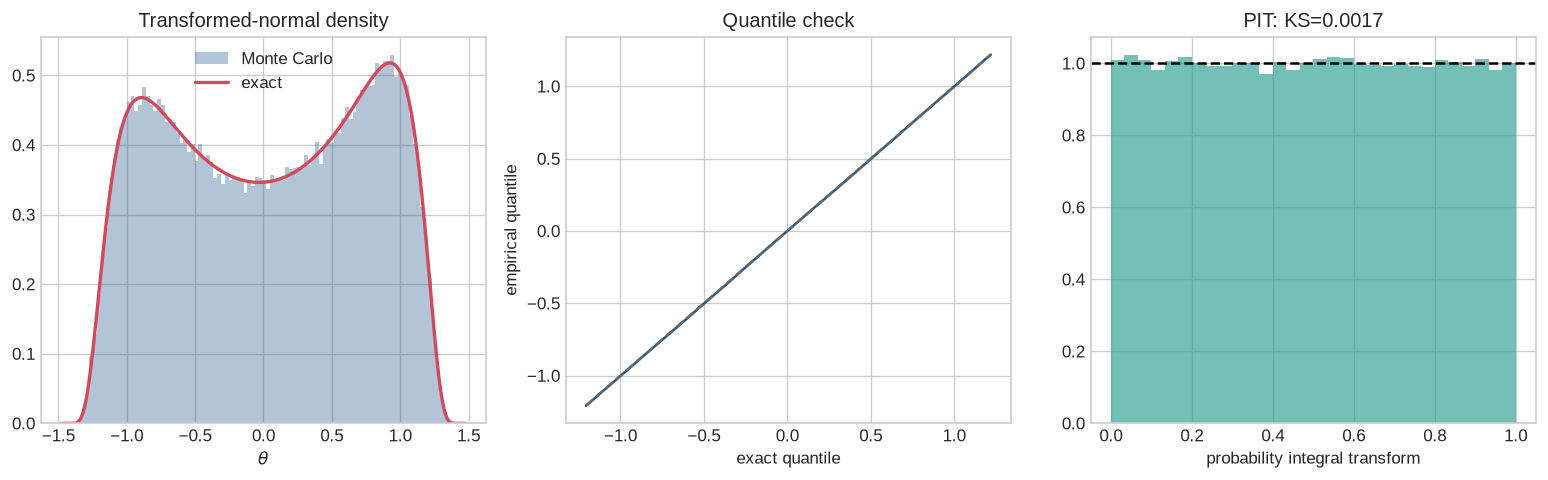

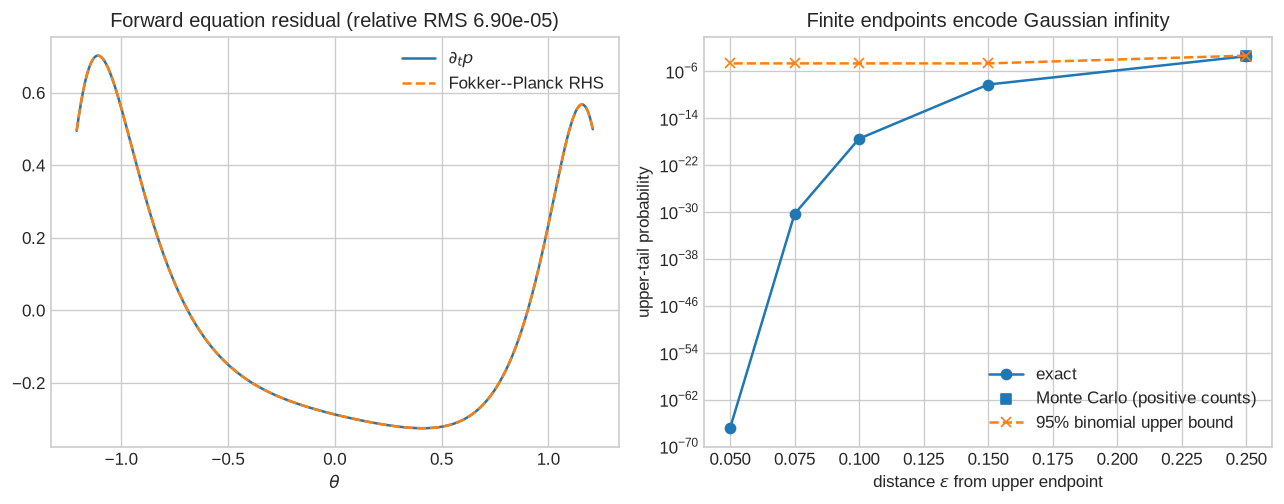

({'pit_ks_statistic': 0.0017267202035672335,
  'pit_ks_pvalue': 0.7259888617047745,
  'density_mass': 0.9999999999999999,
  'density_quadrature_error': 6.565675536075472e-10,
  'semigroup_composed': 0.36948956892833706,
  'semigroup_direct': 0.36948956892833695,
  'semigroup_absolute_error': 1.1102230246251565e-16,
  'semigroup_quadrature_error': 1.1696687839363678e-10,
  'signed_sigma': -0.9},
         h  mean_increment_over_h  mean_increment_over_h_standard_error  \
 0  0.0400              -0.598210                              0.013066   
 1  0.0200              -0.636186                              0.018722   
 2  0.0100              -0.652706                              0.026640   
 3  0.0050              -0.631246                              0.037694   
 4  0.0025              -0.660240                              0.053327   
 
    theory_drift  variance_increment_over_h  \
 0     -0.658949                   1.229241   
 1     -0.658949                   1.261870   
 2     -0

In [7]:
mu_d, sigma_d, c_d, t_d = -0.15, -0.9, 0.7, 0.8
theta0 = 0.22
rng_distribution = np.random.default_rng(BASE_SEED + 5)
n_distribution = 160_000
theta_samples = canonical_exact_phase_step(
    theta0,
    t_d,
    rng_distribution.normal(size=n_distribution),
    mu_d,
    sigma_d,
    c_d,
)
standardized = (
    c_d * np.tan(theta_samples)
    - c_d * np.tan(theta0)
    - mu_d * t_d
) / (abs(sigma_d) * np.sqrt(t_d))
pit = stats.norm.cdf(standardized)
ks_result = stats.kstest(pit, "uniform")

mass, mass_error = quad(
    lambda v: canonical_phase_density(v, theta0, t_d, mu_d, sigma_d, c_d),
    -np.pi / 2.0,
    np.pi / 2.0,
    epsabs=1e-11,
)
split = 0.31
destination = -0.36
composed, composition_error = quad(
    lambda q: canonical_phase_density(destination, q, t_d - split, mu_d, sigma_d, c_d)
    * canonical_phase_density(q, theta0, split, mu_d, sigma_d, c_d),
    -np.pi / 2.0,
    np.pi / 2.0,
    epsabs=2e-10,
)
direct = canonical_phase_density(destination, theta0, t_d, mu_d, sigma_d, c_d)

distribution_summary = {
    "pit_ks_statistic": float(ks_result.statistic),
    "pit_ks_pvalue": float(ks_result.pvalue),
    "density_mass": float(mass),
    "density_quadrature_error": float(mass_error),
    "semigroup_composed": float(composed),
    "semigroup_direct": float(direct),
    "semigroup_absolute_error": float(abs(composed - direct)),
    "semigroup_quadrature_error": float(composition_error),
    "signed_sigma": sigma_d,
}
save_json(distribution_summary, "distribution_summary.json")

probabilities = np.linspace(0.01, 0.99, 99)
empirical_quantiles = np.quantile(theta_samples, probabilities)
exact_y_quantiles = (
    c_d * np.tan(theta0)
    + mu_d * t_d
    + abs(sigma_d) * np.sqrt(t_d) * stats.norm.ppf(probabilities)
)
exact_quantiles = np.arctan(exact_y_quantiles / c_d)
quantiles = save_table(
    pd.DataFrame(
        {
            "probability": probabilities,
            "empirical": empirical_quantiles,
            "exact": exact_quantiles,
            "error": empirical_quantiles - exact_quantiles,
        }
    ),
    "phase_quantiles.csv",
)

generator_rows = []
local_theta = 0.35
generator_h = (0.04, 0.02, 0.01, 0.005, 0.0025)
generator_samples = 180_000
generator_seed_offsets = tuple(range(50, 55))
theory_drift, theory_diffusion = canonical_phase_coefficients(
    local_theta, mu_d, sigma_d, c_d
)
for h, seed_offset in zip(generator_h, generator_seed_offsets, strict=True):
    rng_local = np.random.default_rng(BASE_SEED + seed_offset)
    next_theta = canonical_exact_phase_step(
        local_theta,
        h,
        rng_local.normal(size=generator_samples),
        mu_d,
        sigma_d,
        c_d,
    )
    delta = next_theta - local_theta
    centered_square = (delta - np.mean(delta)) ** 2
    generator_rows.append(
        {
            "h": h,
            "mean_increment_over_h": np.mean(delta) / h,
            "mean_increment_over_h_standard_error": stats.sem(delta) / h,
            "theory_drift": float(theory_drift),
            "variance_increment_over_h": np.var(delta, ddof=1) / h,
            "variance_increment_over_h_standard_error": stats.sem(
                centered_square
            )
            / h,
            "theory_diffusion_squared": float(theory_diffusion**2),
        }
    )
generator_checks = save_table(
    pd.DataFrame(generator_rows),
    "small_time_generator_checks.csv",
)

fp_theta = np.linspace(-1.25, 1.25, 1201)
fp_dx = fp_theta[1] - fp_theta[0]
fp_t, fp_dt = 0.65, 1e-5
p_minus = canonical_phase_density(fp_theta, theta0, fp_t - fp_dt, mu_d, sigma_d, c_d)
p_center = canonical_phase_density(fp_theta, theta0, fp_t, mu_d, sigma_d, c_d)
p_plus = canonical_phase_density(fp_theta, theta0, fp_t + fp_dt, mu_d, sigma_d, c_d)
time_derivative = (p_plus - p_minus) / (2.0 * fp_dt)
fp_drift, fp_diffusion = canonical_phase_coefficients(fp_theta, mu_d, sigma_d, c_d)
flux_drift = np.gradient(fp_drift * p_center, fp_dx, edge_order=2)
flux_diffusion = np.gradient(
    np.gradient(fp_diffusion**2 * p_center, fp_dx, edge_order=2),
    fp_dx,
    edge_order=2,
)
fp_rhs = -flux_drift + 0.5 * flux_diffusion
interior = slice(20, -20)
fp_relative_rms = np.sqrt(np.mean((time_derivative[interior] - fp_rhs[interior]) ** 2)) / np.sqrt(
    np.mean(time_derivative[interior] ** 2)
)
save_json(
    {"fokker_planck_relative_rms_residual": float(fp_relative_rms)},
    "fokker_planck_residual.json",
)

tail_rows = []
for epsilon in (0.25, 0.15, 0.10, 0.075, 0.05):
    threshold_y = c_d / np.tan(epsilon)
    mean_y = c_d * np.tan(theta0) + mu_d * t_d
    exact_upper = stats.norm.sf(
        (threshold_y - mean_y) / (abs(sigma_d) * np.sqrt(t_d))
    )
    tail_count = int(np.sum(theta_samples > np.pi / 2.0 - epsilon))
    empirical_upper = tail_count / n_distribution
    clopper_pearson_upper = (
        1.0
        if tail_count == n_distribution
        else stats.beta.ppf(
            0.975,
            tail_count + 1,
            n_distribution - tail_count,
        )
    )
    tail_rows.append(
        {
            "epsilon": epsilon,
            "equivalent_y_threshold": threshold_y,
            "exact_upper_tail": exact_upper,
            "observed_count": tail_count,
            "empirical_upper_tail": empirical_upper,
            "model_based_monte_carlo_se": np.sqrt(
                exact_upper * (1.0 - exact_upper) / n_distribution
            ),
            "clopper_pearson_95_upper": clopper_pearson_upper,
        }
    )
endpoint_tails = save_table(pd.DataFrame(tail_rows), "endpoint_tails.csv")

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.1))
density_grid = np.linspace(-1.48, 1.48, 700)
axes[0].hist(theta_samples, bins=100, density=True, alpha=0.35, color="#235789", label="Monte Carlo")
axes[0].plot(
    density_grid,
    canonical_phase_density(density_grid, theta0, t_d, mu_d, sigma_d, c_d),
    color="#d1495b",
    lw=2,
    label="exact",
)
axes[0].set_title("Transformed-normal density")
axes[0].set_xlabel(r"$\theta$")
axes[0].legend()
axes[1].plot(exact_quantiles, empirical_quantiles, color="#235789")
bounds = [exact_quantiles.min(), exact_quantiles.max()]
axes[1].plot(bounds, bounds, "--", color="0.4")
axes[1].set_xlabel("exact quantile")
axes[1].set_ylabel("empirical quantile")
axes[1].set_title("Quantile check")
axes[2].hist(pit, bins=30, density=True, color="#2a9d8f", alpha=0.65)
axes[2].axhline(1.0, color="black", ls="--")
axes[2].set_xlabel("probability integral transform")
axes[2].set_title(f"PIT: KS={ks_result.statistic:.4f}")
save_figure(fig, "f07_transition_diagnostics")

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.3))
axes[0].plot(fp_theta[interior], time_derivative[interior], label=r"$\partial_t p$")
axes[0].plot(fp_theta[interior], fp_rhs[interior], "--", label="Fokker--Planck RHS")
axes[0].set_title(f"Forward equation residual (relative RMS {fp_relative_rms:.2e})")
axes[0].set_xlabel(r"$\theta$")
axes[0].legend()
axes[1].semilogy(endpoint_tails["epsilon"], endpoint_tails["exact_upper_tail"], "o-", label="exact")
axes[1].scatter(
    endpoint_tails["epsilon"],
    endpoint_tails["empirical_upper_tail"].replace(0.0, np.nan),
    marker="s",
    label="Monte Carlo (positive counts)",
)
axes[1].semilogy(
    endpoint_tails["epsilon"],
    endpoint_tails["clopper_pearson_95_upper"],
    "x--",
    label="95% binomial upper bound",
)
axes[1].set_xlabel(r"distance $\epsilon$ from upper endpoint")
axes[1].set_ylabel("upper-tail probability")
axes[1].set_title("Finite endpoints encode Gaussian infinity")
axes[1].legend()
save_figure(fig, "f08_generator_and_endpoint_checks")
distribution_summary, generator_checks, endpoint_tails

## 8. Cayley compactification

\[ U==e^{i}, (Y/c). \]

This transform is lossless and has constant radius, but its angular diffusion is state dependent and it is not ordinary circular Brownian motion.

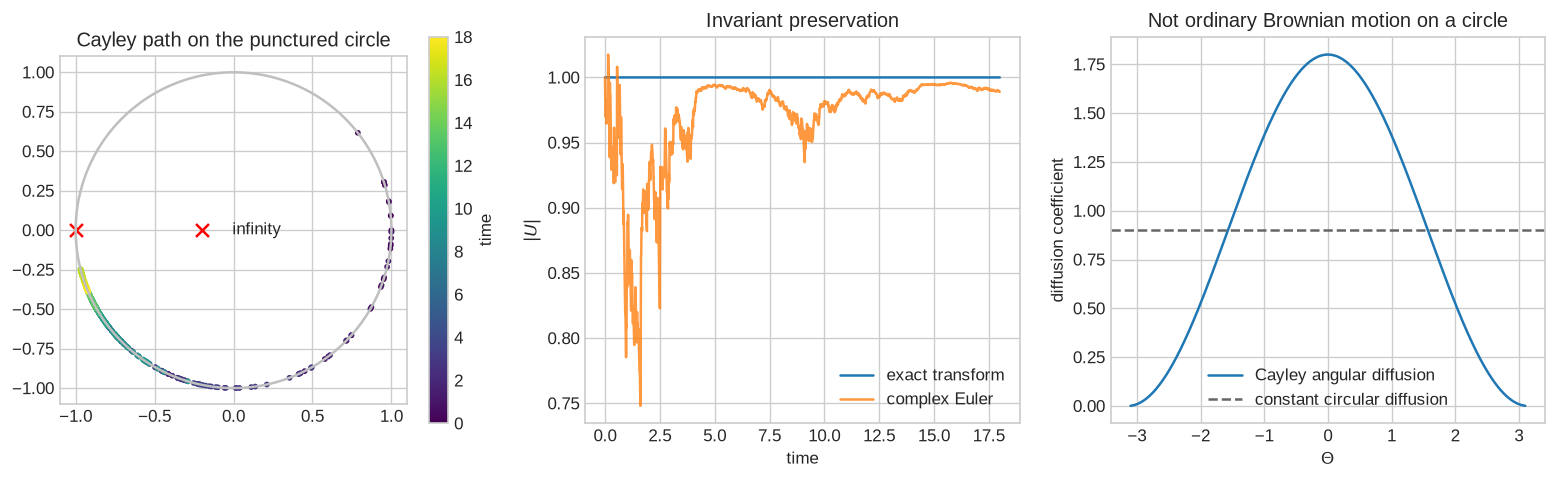

In [8]:
rng_cayley = np.random.default_rng(BASE_SEED + 6)
cayley_steps, cayley_h = 1800, 0.01
cayley_dw = rng_cayley.normal(scale=np.sqrt(cayley_h), size=cayley_steps)
cayley_y = np.concatenate([[0.0], np.cumsum(0.1 * cayley_h + 0.9 * cayley_dw)])
cayley_theta = cayley_phase(cayley_y, 1.0)
cayley_u = cayley_transform(cayley_y, 1.0)
inverse_y = cayley_inverse(cayley_u, 1.0)

# Euler applied directly to the complex SDE does not exactly preserve
# the circle, while the transform does.
direct_em = np.empty(cayley_steps + 1, dtype=complex)
direct_em[0] = 1.0 + 0.0j
for index, dw in enumerate(cayley_dw):
    drift, diffusion = cayley_complex_coefficients(direct_em[index], 0.1, 0.9, 1.0)
    direct_em[index + 1] = direct_em[index] + drift * cayley_h + diffusion * dw

cayley_evidence = pd.DataFrame(
    [
        ("exact transform max modulus error", np.max(np.abs(np.abs(cayley_u) - 1.0))),
        ("inverse max error", np.max(np.abs(inverse_y - cayley_y))),
        ("complex Euler max modulus error", np.max(np.abs(np.abs(direct_em) - 1.0))),
        ("minimum distance to missing point", np.min(np.abs(cayley_u + 1.0))),
    ],
    columns=["metric", "value"],
)
save_table(cayley_evidence, "cayley_invariants.csv")

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.1))
circle = np.linspace(-np.pi, np.pi, 600)
axes[0].plot(np.cos(circle), np.sin(circle), color="0.75")
sc = axes[0].scatter(
    cayley_u.real[::5],
    cayley_u.imag[::5],
    c=np.arange(cayley_u.size)[::5] * cayley_h,
    s=6,
    cmap="viridis",
)
axes[0].scatter([-1.0], [0.0], marker="x", color="red", s=60, label="infinity")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Cayley path on the punctured circle")
axes[0].legend()
fig.colorbar(sc, ax=axes[0], label="time")
axes[1].plot(np.arange(cayley_u.size) * cayley_h, np.abs(cayley_u), label="exact transform")
axes[1].plot(np.arange(direct_em.size) * cayley_h, np.abs(direct_em), alpha=0.8, label="complex Euler")
axes[1].set_xlabel("time")
axes[1].set_ylabel(r"$|U|$")
axes[1].set_title("Invariant preservation")
axes[1].legend()
phase_axis = np.linspace(-3.1, 3.1, 600)
_, cayley_diffusion = cayley_phase_coefficients(phase_axis, 0.1, 0.9, 1.0)
axes[2].plot(phase_axis, cayley_diffusion, label="Cayley angular diffusion")
axes[2].axhline(0.9, ls="--", color="0.4", label="constant circular diffusion")
axes[2].set_xlabel(r"$\Theta$")
axes[2].set_ylabel("diffusion coefficient")
axes[2].set_title("Not ordinary Brownian motion on a circle")
axes[2].legend()
save_figure(fig, "f09_cayley_compactification")
cayley_evidence

## 9. Transported addition

The tangent/arctangent operation is an exact abelian group law because it is real addition in another coordinate. It is not ordinary angular addition or ordinary complex multiplication.

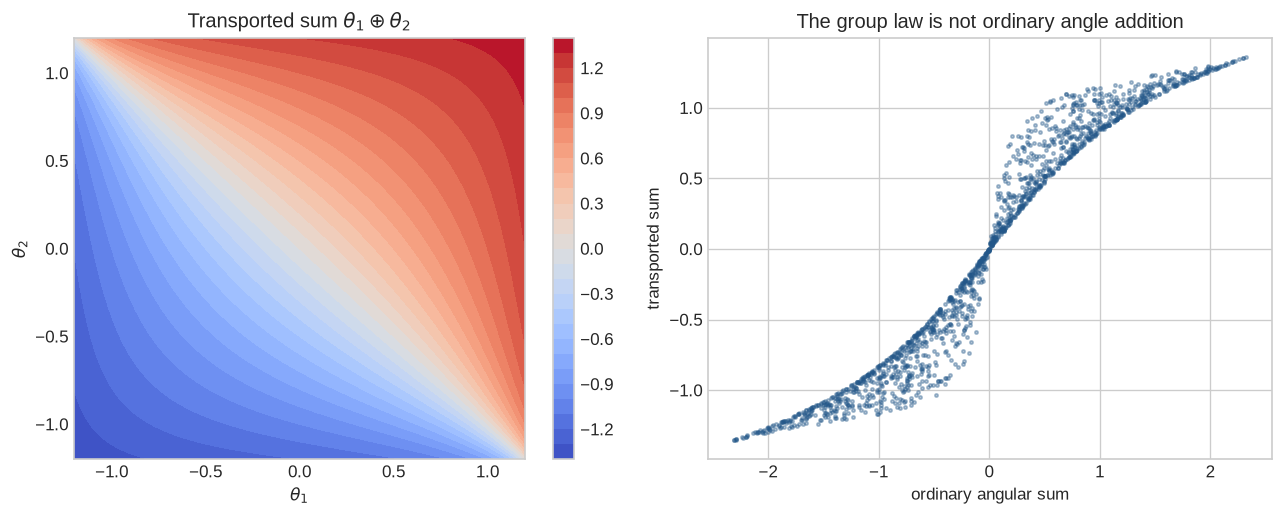

In [9]:
rng_group = np.random.default_rng(BASE_SEED + 7)
group_a = rng_group.uniform(-1.2, 1.2, 80_000)
group_b = rng_group.uniform(-1.2, 1.2, 80_000)
group_c = rng_group.uniform(-1.2, 1.2, 80_000)
combined = transported_add(group_a, group_b)
associativity_left = transported_add(combined, group_c)
associativity_right = transported_add(group_a, transported_add(group_b, group_c))
group_evidence = pd.DataFrame(
    [
        ("tangent addition max error", np.max(np.abs(np.tan(combined) - np.tan(group_a) - np.tan(group_b)))),
        ("associativity max error", np.max(np.abs(associativity_left - associativity_right))),
        ("inverse max error", np.max(np.abs(transported_add(group_a, -group_a)))),
        ("ordinary angle difference RMS", np.sqrt(np.mean((combined - (group_a + group_b)) ** 2))),
    ],
    columns=["metric", "value"],
)
save_table(group_evidence, "transported_group_checks.csv")

grid_group = np.linspace(-1.2, 1.2, 180)
aa, bb = np.meshgrid(grid_group, grid_group)
operation = transported_add(aa, bb)
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.4))
image = axes[0].contourf(aa, bb, operation, levels=30, cmap="coolwarm")
axes[0].set_xlabel(r"$\theta_1$")
axes[0].set_ylabel(r"$\theta_2$")
axes[0].set_title(r"Transported sum $\theta_1\oplus\theta_2$")
fig.colorbar(image, ax=axes[0])
axes[1].scatter(
    (group_a + group_b)[::50],
    combined[::50],
    s=4,
    alpha=0.35,
    color="#235789",
)
axes[1].set_xlabel("ordinary angular sum")
axes[1].set_ylabel("transported sum")
axes[1].set_title("The group law is not ordinary angle addition")
save_figure(fig, "f10_transported_group")
group_evidence

## 10. Additive half-turn versus multiplicative winding

A compatible multiplicative log process has

\[ Z_t=Z_0e<sup>{(/)\_t}e</sup>{i\_t}, \_t=(t+W_t), \]

so its unwrapped phase can wind. It is a different SDE from the additive affine process.

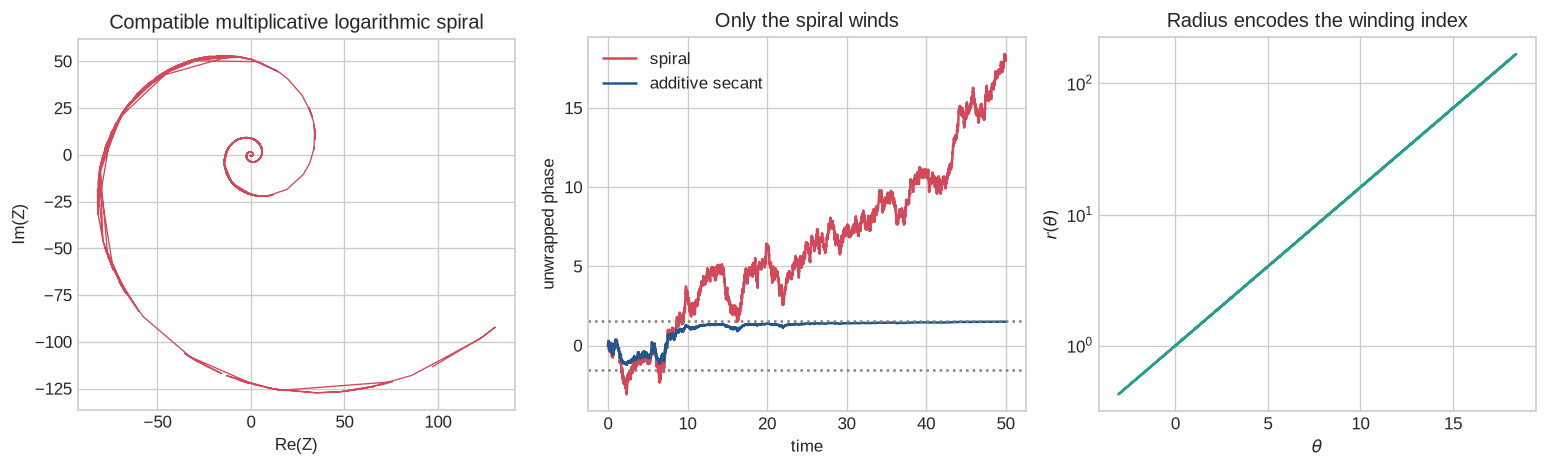

In [10]:
rng_spiral = np.random.default_rng(BASE_SEED + 8)
spiral_h, spiral_horizon = 0.01, 50.0
spiral_times = np.arange(0.0, spiral_horizon + spiral_h, spiral_h)
spiral_w = np.concatenate(
    [[0.0], np.cumsum(rng_spiral.normal(scale=np.sqrt(spiral_h), size=spiral_times.size - 1))]
)
spiral_b = 0.32 + 1.15j
spiral_gamma = 0.18
spiral_kappa = spiral_gamma * spiral_b
spiral_theta = spiral_phase(spiral_times, spiral_w, spiral_kappa, spiral_b)
spiral_z = spiral_state(1.0 + 0.0j, spiral_theta, spiral_b)
direct_spiral = np.exp(spiral_kappa * spiral_times + spiral_b * spiral_w)
additive_theta = canonical_phase(
    spiral_gamma * spiral_times + spiral_w,
    1.0,
)
spiral_evidence = pd.DataFrame(
    [
        ("spiral reconstruction max error", np.max(np.abs(spiral_z - direct_spiral))),
        ("spiral unwrapped phase span", np.ptp(spiral_theta)),
        ("spiral phase span in turns", np.ptp(spiral_theta) / (2.0 * np.pi)),
        ("additive phase span", np.ptp(additive_theta)),
        ("additive theoretical maximum span", np.pi),
    ],
    columns=["metric", "value"],
)
save_table(spiral_evidence, "spiral_winding.csv")

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0))
path_slice = slice(None, None, 4)
axes[0].plot(spiral_z.real[path_slice], spiral_z.imag[path_slice], lw=0.8, color="#d1495b")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Compatible multiplicative logarithmic spiral")
axes[0].set_xlabel("Re(Z)")
axes[0].set_ylabel("Im(Z)")
axes[1].plot(spiral_times, spiral_theta, color="#d1495b", label="spiral")
axes[1].plot(spiral_times, additive_theta, color="#235789", label="additive secant")
axes[1].axhline(np.pi / 2.0, color="0.5", ls=":")
axes[1].axhline(-np.pi / 2.0, color="0.5", ls=":")
axes[1].set_xlabel("time")
axes[1].set_ylabel("unwrapped phase")
axes[1].set_title("Only the spiral winds")
axes[1].legend()
axes[2].semilogy(spiral_theta, spiral_radius(spiral_theta, spiral_b), color="#2a9d8f")
axes[2].set_xlabel(r"$\theta$")
axes[2].set_ylabel(r"$r(\theta)$")
axes[2].set_title("Radius encodes the winding index")
save_figure(fig, "f11_additive_vs_spiral")
spiral_evidence

## 11. Rigidity diagnostics

Constant additive diffusion requires a constant tangent direction. Constant multiplicative diffusion requires a constant logarithmic tangent (F’/F). An arbitrary polar curve has neither property.

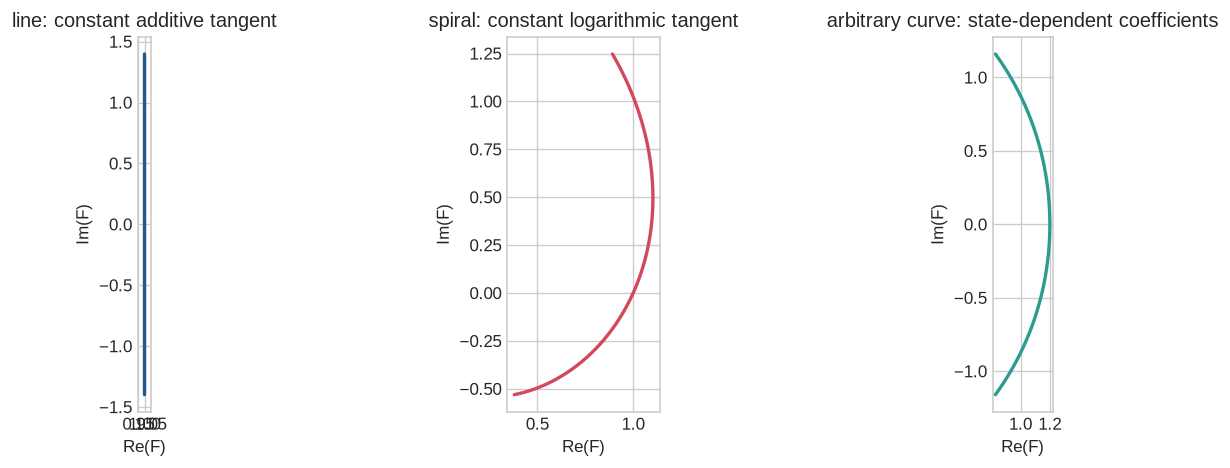

In [11]:
rigidity_theta = np.linspace(-0.95, 0.95, 2001)

line_f = 1.0 + 1j * np.tan(rigidity_theta)
line_fp = 1j / np.cos(rigidity_theta) ** 2
line_s = np.cos(rigidity_theta) ** 2
line_noise = line_fp * line_s

spiral_k, spiral_beta = 0.45, 0.8
spiral_f = np.exp((spiral_k + 1j) * rigidity_theta)
spiral_fp = (spiral_k + 1j) * spiral_f
spiral_relative_noise = spiral_fp * spiral_beta / spiral_f

arbitrary_r = 1.2 + 0.25 * rigidity_theta**2
arbitrary_rp = 0.5 * rigidity_theta
arbitrary_f = arbitrary_r * np.exp(1j * rigidity_theta)
arbitrary_fp = (arbitrary_rp + 1j * arbitrary_r) * np.exp(1j * rigidity_theta)
arbitrary_s = 0.7
arbitrary_additive_noise = arbitrary_fp * arbitrary_s
arbitrary_relative_noise = arbitrary_fp * arbitrary_s / arbitrary_f

def centered_rms(values):
    return np.sqrt(np.mean(np.abs(values - np.mean(values)) ** 2))

rigidity = pd.DataFrame(
    [
        {
            "curve": "line",
            "additive_noise_centered_rms": centered_rms(line_noise),
            "multiplicative_noise_centered_rms": centered_rms(line_noise / line_f),
        },
        {
            "curve": "logarithmic spiral",
            "additive_noise_centered_rms": centered_rms(spiral_fp * spiral_beta),
            "multiplicative_noise_centered_rms": centered_rms(spiral_relative_noise),
        },
        {
            "curve": "arbitrary quadratic radius",
            "additive_noise_centered_rms": centered_rms(arbitrary_additive_noise),
            "multiplicative_noise_centered_rms": centered_rms(arbitrary_relative_noise),
        },
    ]
)
save_table(rigidity, "rigidity_residuals.csv")

fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.0))
axes[0].plot(line_f.real, line_f.imag, color="#235789", lw=2)
axes[0].set_title("line: constant additive tangent")
axes[1].plot(spiral_f.real, spiral_f.imag, color="#d1495b", lw=2)
axes[1].set_title("spiral: constant logarithmic tangent")
axes[2].plot(arbitrary_f.real, arbitrary_f.imag, color="#2a9d8f", lw=2)
axes[2].set_title("arbitrary curve: state-dependent coefficients")
for axis in axes:
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("Re(F)")
    axis.set_ylabel("Im(F)")
save_figure(fig, "f12_rigidity_families")
rigidity

## 12. Time-dependent moving-line fallback

Noncollinear drift and diffusion do admit a polar representation with (R(t,)), except when a support line passes through the origin. This is one stochastic variable plus explicit time—not a time-independent one-phase form.

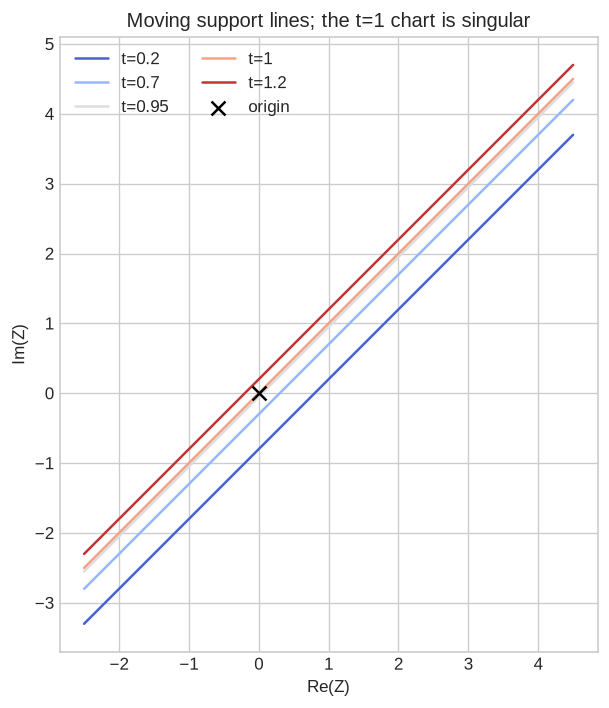

In [12]:
moving_z0 = 1.0 + 0.0j
moving_a = 1.0j
moving_b = 1.0 + 1.0j
moving_times = (0.2, 0.7, 0.95, 1.0, 1.2)
moving_records = []
fig, ax = plt.subplots(figsize=(7.2, 6.0))
colors = plt.cm.coolwarm(np.linspace(0.05, 0.95, len(moving_times)))
w_line = np.linspace(-3.5, 3.5, 500)
for color, t_value in zip(colors, moving_times):
    direct = moving_z0 + moving_a * t_value + moving_b * w_line
    ax.plot(direct.real, direct.imag, color=color, label=f"t={t_value:g}")
    try:
        theta = moving_line_phase(t_value, w_line, moving_z0, moving_a, moving_b)
        represented = moving_line_state(t_value, theta, moving_z0, moving_a, moving_b)
        error = np.max(np.abs(represented - direct))
        status = "chart valid"
    except ValueError:
        error = np.nan
        status = "support line crosses origin"
    moving_records.append(
        {
            "time": t_value,
            "status": status,
            "max_reconstruction_error": error,
        }
    )
ax.scatter([0.0], [0.0], marker="x", color="black", s=70, zorder=4, label="origin")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Re(Z)")
ax.set_ylabel("Im(Z)")
ax.set_title("Moving support lines; the t=1 chart is singular")
ax.legend(ncol=2)
save_figure(fig, "f13_moving_line_fallback")
moving_evidence = save_table(pd.DataFrame(moving_records), "moving_line_fallback.csv")
moving_evidence

## 13. Vector geometry and negative controls

(CR^2), but a phase curve has differential rank one. A one-driver hypoelliptic system can nevertheless have a full-rank terminal law because drift propagates noise into another state direction.

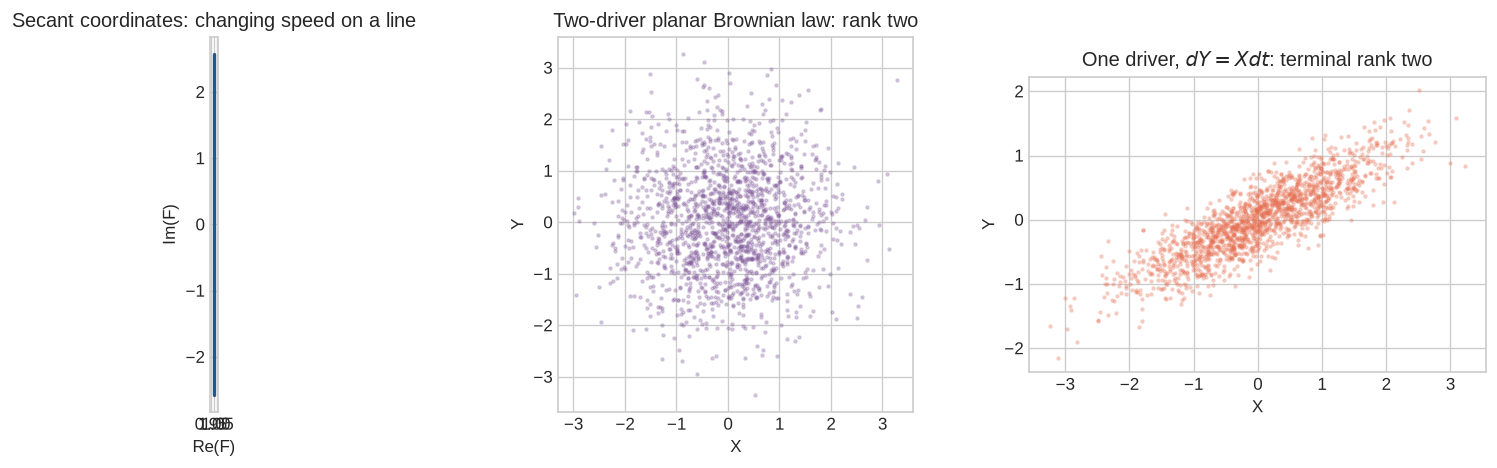

In [13]:
vector_theta = np.linspace(-1.2, 1.2, 500)
vector_f = 1.0 + 1j * np.tan(vector_theta)
vector_fp = 1j / np.cos(vector_theta) ** 2
vector_fpp = 2j * np.tan(vector_theta) / np.cos(vector_theta) ** 2
secant_curvature = np.imag(np.conjugate(vector_fp) * vector_fpp) / np.abs(vector_fp) ** 3

rng_vector = np.random.default_rng(BASE_SEED + 9)
vector_n = 50_000
planar = rng_vector.normal(size=(vector_n, 2))
planar_cov = np.cov(planar, rowvar=False)

hypo_steps, hypo_h = 128, 1.0 / 128.0
x_hypo = np.zeros(vector_n)
y_hypo = np.zeros(vector_n)
for _ in range(hypo_steps):
    y_hypo += x_hypo * hypo_h
    x_hypo += rng_vector.normal(scale=np.sqrt(hypo_h), size=vector_n)
hypo_cov = np.cov(np.column_stack([x_hypo, y_hypo]), rowvar=False)
hypo_theory = np.array([[1.0, 0.5], [0.5, 1.0 / 3.0]])

tangent = np.array([0.0, 0.8])
curve_cov = phase_noise_covariance(tangent)

vector_rank_rows = []
for name, covariance in [
    ("one-phase tangent covariance", curve_cov),
    ("planar Brownian terminal covariance", planar_cov),
    ("hypoelliptic terminal covariance empirical", hypo_cov),
    ("hypoelliptic terminal covariance theory", hypo_theory),
]:
    eigenvalues = np.linalg.eigvalsh(covariance)
    vector_rank_rows.append(
        {
            "case": name,
            "eigenvalue_1": eigenvalues[0],
            "eigenvalue_2": eigenvalues[1],
            "determinant": np.linalg.det(covariance),
            "rank_tol_1e-6": np.linalg.matrix_rank(covariance, tol=1e-6),
        }
    )
vector_rank = save_table(pd.DataFrame(vector_rank_rows), "vector_rank_controls.csv")
save_json(
    {
        "secant_max_absolute_curvature": float(np.max(np.abs(secant_curvature))),
        "hypoelliptic_covariance_max_error": float(np.max(np.abs(hypo_cov - hypo_theory))),
    },
    "vector_geometry_summary.json",
)

fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.0))
sample_idx = slice(None, None, 30)
axes[0].plot(vector_f.real, vector_f.imag, color="#235789", lw=2)
selected_idx = np.arange(50, 450, 80)
for idx in selected_idx:
    tangent_unit = vector_fp[idx] / abs(vector_fp[idx])
    normal_unit = 1j * tangent_unit
    point = vector_f[idx]
    axes[0].quiver(point.real, point.imag, tangent_unit.real, tangent_unit.imag, color="#d1495b", angles="xy", scale_units="xy", scale=1.8)
    axes[0].quiver(point.real, point.imag, normal_unit.real, normal_unit.imag, color="#2a9d8f", angles="xy", scale_units="xy", scale=1.8)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Secant coordinates: changing speed on a line")
axes[0].set_xlabel("Re(F)")
axes[0].set_ylabel("Im(F)")
axes[1].scatter(planar[sample_idx, 0], planar[sample_idx, 1], s=3, alpha=0.25, color="#7a5195")
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("Two-driver planar Brownian law: rank two")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[2].scatter(x_hypo[sample_idx], y_hypo[sample_idx], s=3, alpha=0.25, color="#e76f51")
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_title(r"One driver, $dY=Xdt$: terminal rank two")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Y")
save_figure(fig, "f14_vector_geometry_and_controls")
vector_rank

## 14. Complex and directional derivatives

Data on one curve determine a tangent derivative, not a unique normal derivative or holomorphic extension. Wirtinger notation is exact for nonholomorphic functions. Complex-step differentiation is a separate established numerical method.

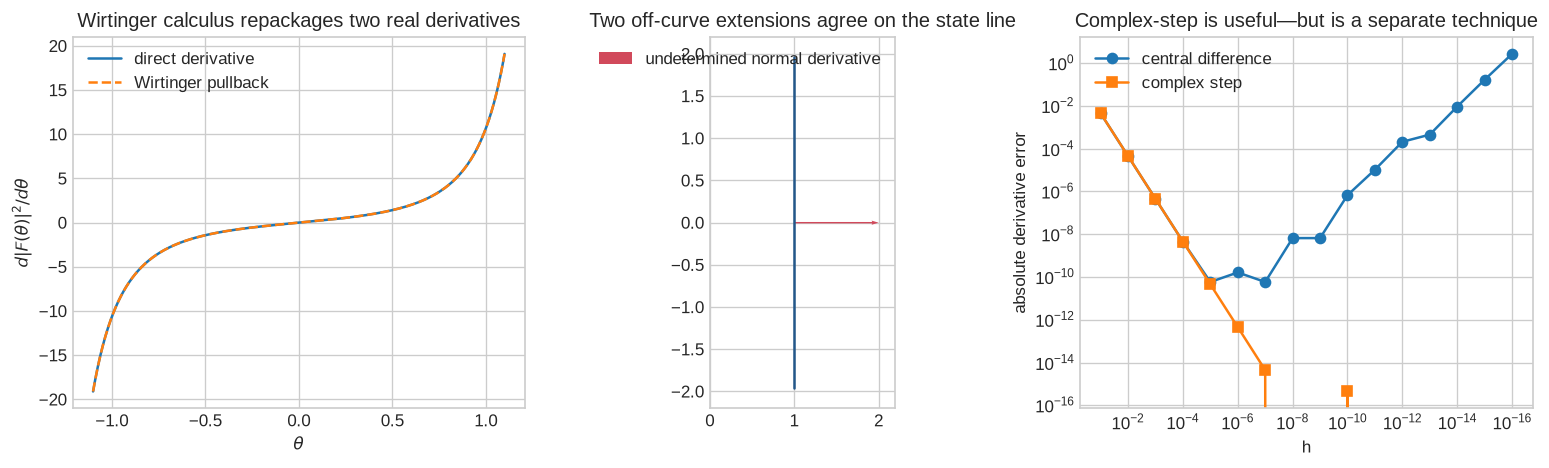

{'wirtinger_pullback_max_error': 3.552713678800501e-15,
 'two_extensions_max_value_difference_on_curve': 0.0,
 'normal_derivative_extension_0': 0.0,
 'normal_derivative_extension_1': 1.0}

In [14]:
derivative_theta = np.linspace(-1.1, 1.1, 800)
derivative_z = 1.0 + 1j * np.tan(derivative_theta)
derivative_fp = 1j / np.cos(derivative_theta) ** 2
# h(z,zbar)=|z|^2 has h_z=zbar and h_zbar=z.
wirtinger_pullback = (
    np.conjugate(derivative_z) * derivative_fp
    + derivative_z * np.conjugate(derivative_fp)
).real
exact_pullback = 2.0 * np.tan(derivative_theta) / np.cos(derivative_theta) ** 2
wirtinger_error = np.max(np.abs(wirtinger_pullback - exact_pullback))

# H0=0 and H1=Re(z)-1 agree on the vertical state line, but their
# derivatives in the real/normal direction are 0 and 1.
on_curve_h1 = derivative_z.real - 1.0

derivative_steps = np.logspace(-1, -16, 16)
x_derivative = 1.0
exact_derivative = np.exp(x_derivative)
central = (
    np.exp(x_derivative + derivative_steps)
    - np.exp(x_derivative - derivative_steps)
) / (2.0 * derivative_steps)
complex_step = np.imag(np.exp(x_derivative + 1j * derivative_steps)) / derivative_steps
derivative_benchmark = save_table(
    pd.DataFrame(
        {
            "h": derivative_steps,
            "central_error": np.abs(central - exact_derivative),
            "complex_step_error": np.abs(complex_step - exact_derivative),
        }
    ),
    "complex_step_benchmark.csv",
)
derivative_summary = save_json(
    {
        "wirtinger_pullback_max_error": float(wirtinger_error),
        "two_extensions_max_value_difference_on_curve": float(np.max(np.abs(on_curve_h1))),
        "normal_derivative_extension_0": 0.0,
        "normal_derivative_extension_1": 1.0,
    },
    "complex_derivative_summary.json",
)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0))
axes[0].plot(derivative_theta, exact_pullback, label="direct derivative")
axes[0].plot(derivative_theta, wirtinger_pullback, "--", label="Wirtinger pullback")
axes[0].set_xlabel(r"$\theta$")
axes[0].set_ylabel(r"$d|F(\theta)|^2/d\theta$")
axes[0].set_title("Wirtinger calculus repackages two real derivatives")
axes[0].legend()
axes[1].plot(derivative_z.real, derivative_z.imag, color="#235789")
axes[1].quiver(1.0, 0.0, 1.0, 0.0, color="#d1495b", angles="xy", scale_units="xy", scale=1, label="undetermined normal derivative")
axes[1].set_xlim(0.0, 2.2)
axes[1].set_ylim(-2.2, 2.2)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("Two off-curve extensions agree on the state line")
axes[1].legend()
axes[2].loglog(derivative_steps, derivative_benchmark["central_error"], "o-", label="central difference")
axes[2].loglog(derivative_steps, derivative_benchmark["complex_step_error"], "s-", label="complex step")
axes[2].invert_xaxis()
axes[2].set_xlabel("h")
axes[2].set_ylabel("absolute derivative error")
axes[2].set_title("Complex-step is useful—but is a separate technique")
axes[2].legend()
save_figure(fig, "f15_complex_derivative_limits")
derivative_summary

## 15. Compactified heat-equation benchmark

The map (x=c) conjugates the heat generator to a variable-coefficient operator on a bounded interval. We compare second-order finite differences at matched degrees of freedom. This tests numerical conditioning and accuracy; it does not claim a new analytic solution.

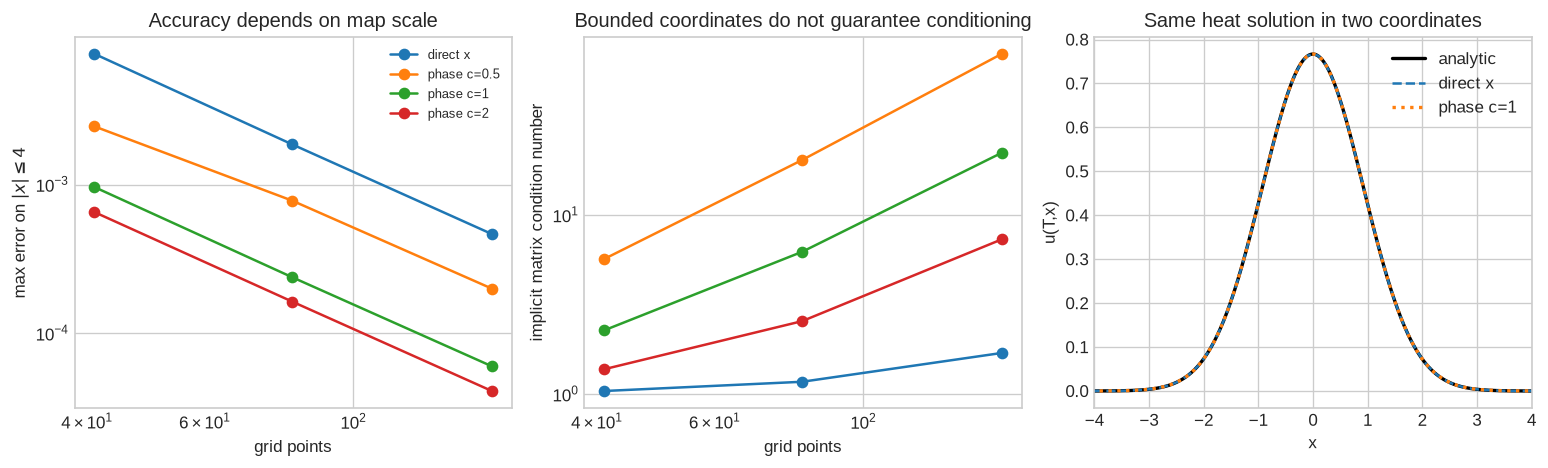

In [15]:
heat_sigma, heat_t, heat_l = 1.0, 0.35, 8.0

def heat_exact(x, t=heat_t):
    denominator = 1.0 + 2.0 * heat_sigma**2 * t
    return np.exp(-(x**2) / denominator) / np.sqrt(denominator)

def solve_heat_x(points):
    grid = np.linspace(-heat_l, heat_l, points)
    dx = grid[1] - grid[0]
    interior = grid[1:-1]
    diffusion = 0.5 * heat_sigma**2
    matrix = sparse.diags(
        [
            np.full(interior.size - 1, diffusion / dx**2),
            np.full(interior.size, -2.0 * diffusion / dx**2),
            np.full(interior.size - 1, diffusion / dx**2),
        ],
        offsets=[-1, 0, 1],
        format="csr",
    )
    initial = np.exp(-interior**2)
    solution = expm_multiply(matrix * heat_t, initial)
    exact = heat_exact(interior)
    central = np.abs(interior) <= 4.0
    condition = np.linalg.cond(
        np.eye(interior.size) - (heat_t / 100.0) * matrix.toarray()
    )
    return {
        "grid": interior,
        "solution": solution,
        "max_error": np.max(np.abs(solution[central] - exact[central])),
        "rms_error": np.sqrt(np.mean((solution[central] - exact[central]) ** 2)),
        "condition": condition,
        "minimum": np.min(solution),
    }

def solve_heat_theta(points, c_map):
    theta_max = np.arctan(heat_l / c_map)
    theta = np.linspace(-theta_max, theta_max, points)
    dtheta = theta[1] - theta[0]
    interior = theta[1:-1]
    x = c_map * np.tan(interior)
    drift, phase_diffusion = canonical_phase_coefficients(
        interior, 0.0, heat_sigma, c_map
    )
    local_diffusion = 0.5 * phase_diffusion**2
    lower = local_diffusion / dtheta**2 - drift / (2.0 * dtheta)
    diagonal = -2.0 * local_diffusion / dtheta**2
    upper = local_diffusion / dtheta**2 + drift / (2.0 * dtheta)
    matrix = sparse.diags(
        [lower[1:], diagonal, upper[:-1]],
        offsets=[-1, 0, 1],
        format="csr",
    )
    initial = np.exp(-x**2)
    solution = expm_multiply(matrix * heat_t, initial)
    exact = heat_exact(x)
    condition = np.linalg.cond(
        np.eye(interior.size) - (heat_t / 100.0) * matrix.toarray()
    )
    central = np.abs(x) <= 4.0
    return {
        "grid": x,
        "solution": solution,
        "max_error": np.max(np.abs(solution[central] - exact[central])),
        "rms_error": np.sqrt(np.mean((solution[central] - exact[central]) ** 2)),
        "condition": condition,
        "minimum": np.min(solution),
    }

pde_rows = []
pde_solutions = {}
for points in (41, 81, 161):
    direct_result = solve_heat_x(points)
    pde_solutions[("direct x", points)] = direct_result
    pde_rows.append(
        {
            "method": "direct x",
            "map_c": np.nan,
            "points": points,
            "max_error_abs_x_le_4": direct_result["max_error"],
            "rms_error_abs_x_le_4": direct_result["rms_error"],
            "implicit_matrix_condition": direct_result["condition"],
            "minimum_solution": direct_result["minimum"],
        }
    )
    for c_map in (0.5, 1.0, 2.0):
        mapped_result = solve_heat_theta(points, c_map)
        pde_solutions[(f"phase c={c_map}", points)] = mapped_result
        pde_rows.append(
            {
                "method": "phase compactification",
                "map_c": c_map,
                "points": points,
                "max_error_abs_x_le_4": mapped_result["max_error"],
                "rms_error_abs_x_le_4": mapped_result["rms_error"],
                "implicit_matrix_condition": mapped_result["condition"],
                "minimum_solution": mapped_result["minimum"],
            }
        )
pde_benchmark = save_table(pd.DataFrame(pde_rows), "pde_compactification.csv")

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0))
for label, group in pde_benchmark.groupby(["method", "map_c"], dropna=False):
    method, map_c = label
    display = method if pd.isna(map_c) else f"phase c={map_c:g}"
    axes[0].loglog(group["points"], group["max_error_abs_x_le_4"], "o-", label=display)
    axes[1].loglog(group["points"], group["implicit_matrix_condition"], "o-", label=display)
axes[0].set_xlabel("grid points")
axes[0].set_ylabel(r"max error on $|x|\leq4$")
axes[0].set_title("Accuracy depends on map scale")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("grid points")
axes[1].set_ylabel("implicit matrix condition number")
axes[1].set_title("Bounded coordinates do not guarantee conditioning")
best = pde_solutions[("phase c=1.0", 161)]
direct_best = pde_solutions[("direct x", 161)]
x_plot = np.linspace(-4.0, 4.0, 500)
axes[2].plot(x_plot, heat_exact(x_plot), color="black", lw=2, label="analytic")
axes[2].plot(direct_best["grid"], direct_best["solution"], "--", label="direct x")
axes[2].plot(best["grid"], best["solution"], ":", lw=2, label="phase c=1")
axes[2].set_xlim(-4.0, 4.0)
axes[2].set_xlabel("x")
axes[2].set_ylabel("u(T,x)")
axes[2].set_title("Same heat solution in two coordinates")
axes[2].legend()
save_figure(fig, "f16_pde_compactification")
pde_benchmark

## 16. Monte Carlo, quasi-Monte Carlo, rare events, and path dependence

With identical random numbers, a lossless reparameterization produces the same estimator and variance. Any variance reduction must come from a changed estimator, proposal, or smoothing—not from replacing (X) by ().

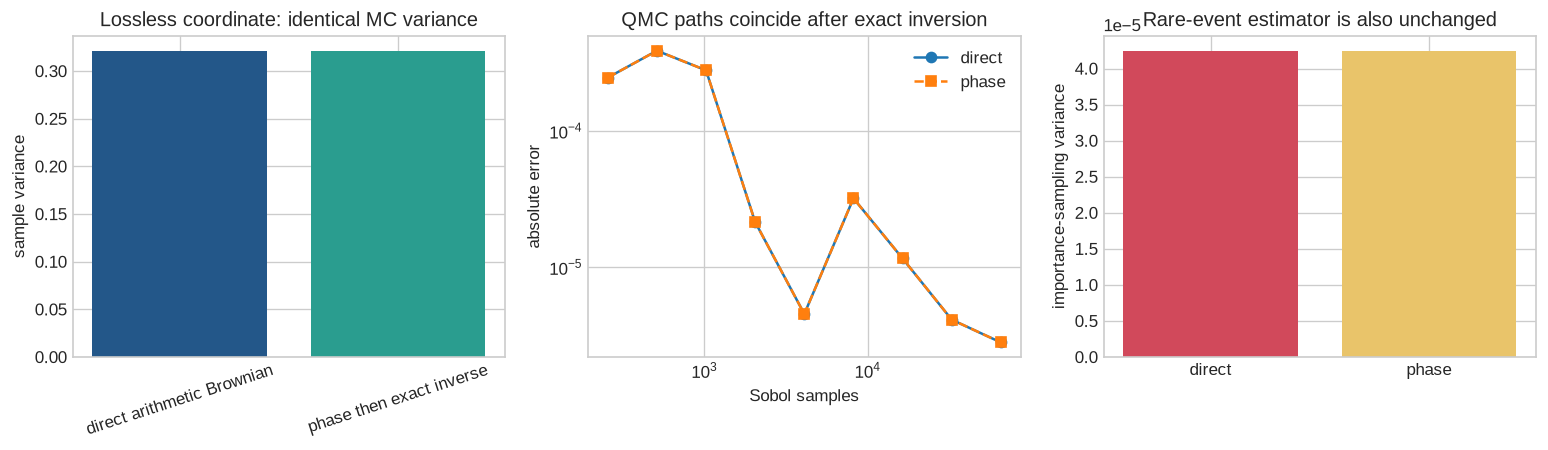

(                    estimator  estimate  sample_variance  standard_error  \
 0  direct arithmetic Brownian  0.363588         0.320663        0.001106   
 1    phase then exact inverse  0.363588         0.320663        0.001106   
 
    absolute_bias_vs_analytic  
 0                   0.002363  
 1                   0.002363  ,
   seed_family      seed  direct_estimate  phase_estimate  direct_minus_phase  \
 0        base  20260725         0.363588        0.363588                 0.0   
 1      second  20360725         0.365608        0.365608                 0.0   
 
    direct_standard_error  
 0               0.001106  
 1               0.001110  ,
            terminal_estimator  normal_draws_per_sample  \
 0  direct arithmetic Brownian                        1   
 1    phase then exact inverse                        1   
 
    stored_stochastic_scalars  forward_transcendental_calls  \
 0                          1                             0   
 1                          1      

In [16]:
mc_mu, mc_sigma, mc_t, mc_c = 0.2, 0.9, 1.3, 1.1
strike = 0.35
rng_mc = np.random.default_rng(BASE_SEED + 10)
mc_n = 2**18
mc_normal = rng_mc.normal(size=mc_n)
mc_x = mc_mu * mc_t + mc_sigma * np.sqrt(mc_t) * mc_normal
mc_theta = canonical_phase(mc_x, mc_c)
mc_reconstructed = canonical_inverse(mc_theta, mc_c)
payoff_direct = np.maximum(mc_x - strike, 0.0)
payoff_phase = np.maximum(mc_reconstructed - strike, 0.0)
normal_d = (mc_mu * mc_t - strike) / (mc_sigma * np.sqrt(mc_t))
bachelier_exact = (
    (mc_mu * mc_t - strike) * stats.norm.cdf(normal_d)
    + mc_sigma * np.sqrt(mc_t) * stats.norm.pdf(normal_d)
)

mc_equivalence = pd.DataFrame(
    [
        {
            "estimator": "direct arithmetic Brownian",
            "estimate": np.mean(payoff_direct),
            "sample_variance": np.var(payoff_direct, ddof=1),
            "standard_error": stats.sem(payoff_direct),
            "absolute_bias_vs_analytic": abs(np.mean(payoff_direct) - bachelier_exact),
        },
        {
            "estimator": "phase then exact inverse",
            "estimate": np.mean(payoff_phase),
            "sample_variance": np.var(payoff_phase, ddof=1),
            "standard_error": stats.sem(payoff_phase),
            "absolute_bias_vs_analytic": abs(np.mean(payoff_phase) - bachelier_exact),
        },
    ]
)
save_table(mc_equivalence, "monte_carlo_equivalence.csv")

rng_mc_second = np.random.default_rng(SECOND_SEED + 10)
mc_normal_second = rng_mc_second.normal(size=mc_n)
mc_x_second = (
    mc_mu * mc_t
    + mc_sigma * np.sqrt(mc_t) * mc_normal_second
)
mc_theta_second = canonical_phase(mc_x_second, mc_c)
mc_phase_second = canonical_inverse(mc_theta_second, mc_c)
mc_seed_replication = save_table(
    pd.DataFrame(
        [
            {
                "seed_family": "base",
                "seed": BASE_SEED,
                "direct_estimate": np.mean(payoff_direct),
                "phase_estimate": np.mean(payoff_phase),
                "direct_minus_phase": np.mean(payoff_direct)
                - np.mean(payoff_phase),
                "direct_standard_error": stats.sem(payoff_direct),
            },
            {
                "seed_family": "second",
                "seed": SECOND_SEED,
                "direct_estimate": np.mean(
                    np.maximum(mc_x_second - strike, 0.0)
                ),
                "phase_estimate": np.mean(
                    np.maximum(mc_phase_second - strike, 0.0)
                ),
                "direct_minus_phase": np.mean(
                    np.maximum(mc_x_second - strike, 0.0)
                )
                - np.mean(
                    np.maximum(mc_phase_second - strike, 0.0)
                ),
                "direct_standard_error": stats.sem(
                    np.maximum(mc_x_second - strike, 0.0)
                ),
            },
        ]
    ),
    "monte_carlo_seed_replication.csv",
)

cost_proxy = save_table(
    pd.DataFrame(
        [
            {
                "terminal_estimator": "direct arithmetic Brownian",
                "normal_draws_per_sample": 1,
                "stored_stochastic_scalars": 1,
                "forward_transcendental_calls": 0,
                "inverse_transcendental_calls": 0,
            },
            {
                "terminal_estimator": "phase then exact inverse",
                "normal_draws_per_sample": 1,
                "stored_stochastic_scalars": 1,
                "forward_transcendental_calls": 1,
                "inverse_transcendental_calls": 1,
            },
        ]
    ),
    "computational_work_proxy.csv",
)

qmc_rows = []
for power in range(8, 17):
    engine = stats.qmc.Sobol(d=1, scramble=True, seed=BASE_SEED + 100 + power)
    uniforms = engine.random_base2(power).ravel()
    normals = stats.norm.ppf(uniforms)
    x_qmc = mc_mu * mc_t + mc_sigma * np.sqrt(mc_t) * normals
    theta_qmc = canonical_phase(x_qmc, mc_c)
    direct_estimate = np.mean(np.maximum(x_qmc - strike, 0.0))
    phase_estimate = np.mean(
        np.maximum(canonical_inverse(theta_qmc, mc_c) - strike, 0.0)
    )
    qmc_rows.append(
        {
            "samples": 2**power,
            "direct_error": abs(direct_estimate - bachelier_exact),
            "phase_error": abs(phase_estimate - bachelier_exact),
            "direct_minus_phase": direct_estimate - phase_estimate,
        }
    )
qmc_evidence = save_table(pd.DataFrame(qmc_rows), "qmc_equivalence.csv")

rare_threshold, proposal_shift = 3.0, 2.8
rare_normal = rng_mc.normal(loc=proposal_shift, scale=1.0, size=180_000)
rare_x = mc_mu * mc_t + mc_sigma * np.sqrt(mc_t) * rare_normal
rare_theta = canonical_phase(rare_x, mc_c)
likelihood_ratio = np.exp(
    -proposal_shift * rare_normal + 0.5 * proposal_shift**2
)
direct_rare_samples = (rare_x > rare_threshold) * likelihood_ratio
phase_threshold = canonical_phase(rare_threshold, mc_c)
phase_rare_samples = (rare_theta > phase_threshold) * likelihood_ratio
rare_exact = stats.norm.sf(
    (rare_threshold - mc_mu * mc_t) / (mc_sigma * np.sqrt(mc_t))
)
rare_evidence = pd.DataFrame(
    [
        {
            "coordinate": "direct",
            "estimate": np.mean(direct_rare_samples),
            "sample_variance": np.var(direct_rare_samples, ddof=1),
            "absolute_error": abs(np.mean(direct_rare_samples) - rare_exact),
        },
        {
            "coordinate": "phase",
            "estimate": np.mean(phase_rare_samples),
            "sample_variance": np.var(phase_rare_samples, ddof=1),
            "absolute_error": abs(np.mean(phase_rare_samples) - rare_exact),
        },
    ]
)
save_table(rare_evidence, "rare_event_equivalence.csv")

# A terminal phase is a terminal-state coordinate, not a path summary.
path_count, path_steps = 24_000, 128
path_dw = rng_mc.normal(
    scale=np.sqrt(mc_t / path_steps),
    size=(path_count, path_steps),
)
path_w = np.cumsum(path_dw, axis=1)
path_x = mc_mu * np.linspace(mc_t / path_steps, mc_t, path_steps) + mc_sigma * path_w
terminal_phase = canonical_phase(path_x[:, -1], mc_c)
barrier_payoff = (np.max(path_x, axis=1) > 1.4).astype(float)
terminal_bins = pd.qcut(terminal_phase, q=30, labels=False, duplicates="drop")
conditional_variances = pd.DataFrame(
    {"bin": terminal_bins, "barrier": barrier_payoff}
).groupby("bin")["barrier"].var()
path_summary = save_json(
    {
        "max_direct_phase_payoff_difference": float(np.max(np.abs(payoff_direct - payoff_phase))),
        "max_state_reconstruction_error": float(np.max(np.abs(mc_x - mc_reconstructed))),
        "mean_barrier_payoff_conditional_variance_given_terminal_phase_bin": float(conditional_variances.mean()),
        "interpretation": "terminal phase does not encode path history; the full phase path remains equivalent to the full scalar path",
    },
    "monte_carlo_summary.json",
)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0))
axes[0].bar(
    mc_equivalence["estimator"],
    mc_equivalence["sample_variance"],
    color=["#235789", "#2a9d8f"],
)
axes[0].tick_params(axis="x", rotation=18)
axes[0].set_ylabel("sample variance")
axes[0].set_title("Lossless coordinate: identical MC variance")
axes[1].loglog(qmc_evidence["samples"], qmc_evidence["direct_error"], "o-", label="direct")
axes[1].loglog(qmc_evidence["samples"], qmc_evidence["phase_error"], "s--", label="phase")
axes[1].set_xlabel("Sobol samples")
axes[1].set_ylabel("absolute error")
axes[1].set_title("QMC paths coincide after exact inversion")
axes[1].legend()
axes[2].bar(
    rare_evidence["coordinate"],
    rare_evidence["sample_variance"],
    color=["#d1495b", "#e9c46a"],
)
axes[2].set_ylabel("importance-sampling variance")
axes[2].set_title("Rare-event estimator is also unchanged")
save_figure(fig, "f17_monte_carlo_equivalence")
mc_equivalence, mc_seed_replication, cost_proxy, rare_evidence, path_summary

## 17. Explicit negative-control register

Each broad implication is paired with a case that would fail if the claim were overstated. The controls distinguish a useful coordinate change from a new stochastic dimension, group, derivative theory, or universal numerical method.

In [17]:
negative_controls = save_table(
    pd.DataFrame(
        [
            (
                "lossless phase for every affine process",
                "random-time noncollinear support",
                "fails: empirical support covariance has rank two",
            ),
            (
                "ordinary polar angle stores a radial continuum",
                "radial affine line",
                "fails: continuum of radii has only two directions",
            ),
            (
                "one Brownian driver always gives terminal rank one",
                "integrated Brownian hypoelliptic system",
                "fails: theoretical terminal covariance determinant is 1/12",
            ),
            (
                "complex curve data determine a holomorphic derivative",
                "two off-curve extensions agreeing on the state line",
                "fails: normal derivatives are 0 and 1",
            ),
            (
                "transported phase addition is ordinary angular addition",
                "tangent/arctangent group comparison",
                "fails: ordinary-angle RMS discrepancy is nonzero",
            ),
            (
                "lossless phase lowers Monte Carlo variance",
                "shared-stream terminal payoff",
                "fails: estimators agree sample by sample",
            ),
            (
                "bounded PDE coordinates guarantee conditioning",
                "three arctangent map scales",
                "fails: conditioning varies strongly with scale",
            ),
            (
                "constant-radius Cayley dynamics are circular Brownian motion",
                "state-dependent angular diffusion",
                "fails: diffusion vanishes near the missing point",
            ),
            (
                "moving-line phase works through origin crossing",
                "noncollinear process at t=1",
                "fails: support line crosses the origin",
            ),
        ],
        columns=["claim_under_test", "negative_control", "outcome"],
    ),
    "negative_controls.csv",
)
negative_controls

## 18. Evidence decision table

The representation passes exactness and geometric-clarity tests. It provides a useful compactification and an invariant-preserving Cayley coordinate. It does not create a second stochastic dimension, holomorphic structure, generic variance reduction, or a universal numerical advantage.

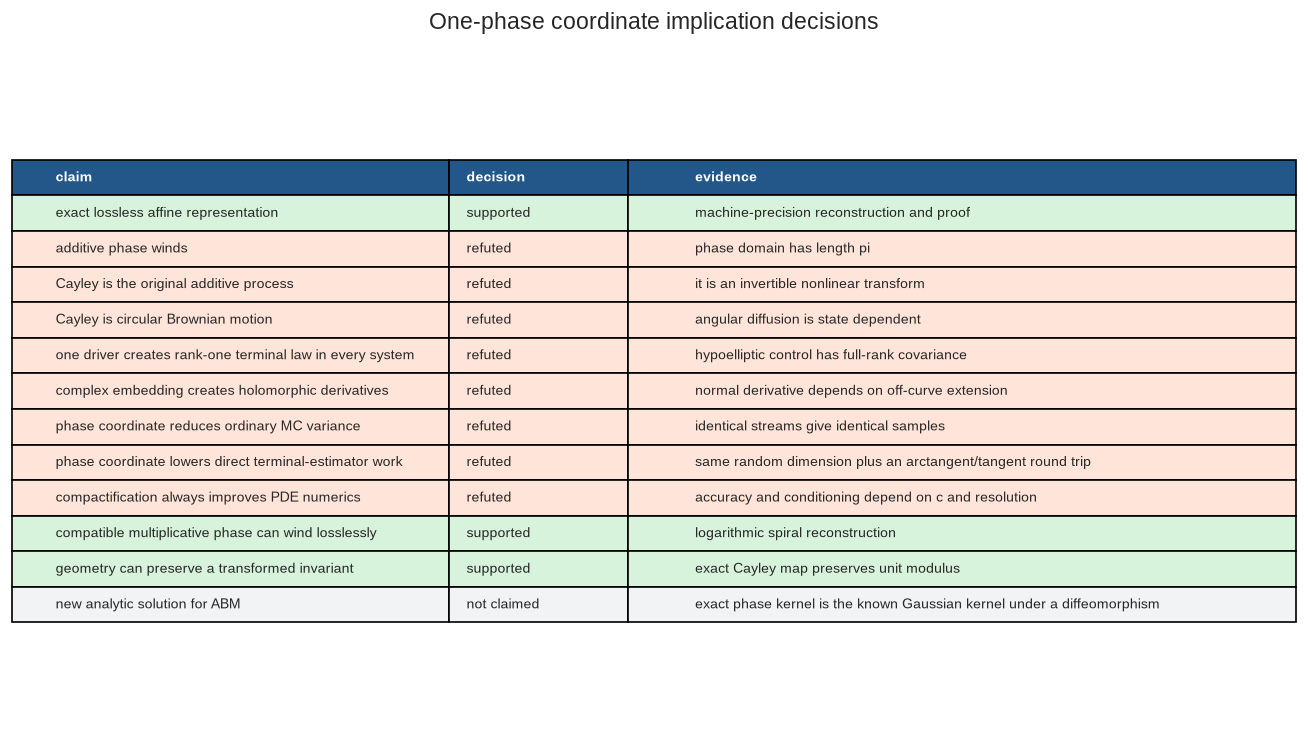

(                                                claim     decision  \
 0                exact lossless affine representation    supported   
 1                                additive phase winds      refuted   
 2             Cayley is the original additive process      refuted   
 3                  Cayley is circular Brownian motion      refuted   
 4   one driver creates rank-one terminal law in ev...      refuted   
 5   complex embedding creates holomorphic derivatives      refuted   
 6       phase coordinate reduces ordinary MC variance      refuted   
 7   phase coordinate lowers direct terminal-estima...      refuted   
 8       compactification always improves PDE numerics      refuted   
 9   compatible multiplicative phase can wind lossl...    supported   
 10      geometry can preserve a transformed invariant    supported   
 11                      new analytic solution for ABM  not claimed   
 
                                              evidence  
 0          machin

In [18]:
decisions = pd.DataFrame(
    [
        ("exact lossless affine representation", "supported", "machine-precision reconstruction and proof"),
        ("additive phase winds", "refuted", "phase domain has length pi"),
        ("Cayley is the original additive process", "refuted", "it is an invertible nonlinear transform"),
        ("Cayley is circular Brownian motion", "refuted", "angular diffusion is state dependent"),
        ("one driver creates rank-one terminal law in every system", "refuted", "hypoelliptic control has full-rank covariance"),
        ("complex embedding creates holomorphic derivatives", "refuted", "normal derivative depends on off-curve extension"),
        ("phase coordinate reduces ordinary MC variance", "refuted", "identical streams give identical samples"),
        ("phase coordinate lowers direct terminal-estimator work", "refuted", "same random dimension plus an arctangent/tangent round trip"),
        ("compactification always improves PDE numerics", "refuted", "accuracy and conditioning depend on c and resolution"),
        ("compatible multiplicative phase can wind losslessly", "supported", "logarithmic spiral reconstruction"),
        ("geometry can preserve a transformed invariant", "supported", "exact Cayley map preserves unit modulus"),
        ("new analytic solution for ABM", "not claimed", "exact phase kernel is the known Gaussian kernel under a diffeomorphism"),
    ],
    columns=["claim", "decision", "evidence"],
)
save_table(decisions, "decision_table.csv")

experiment_parameters = save_json(
    {
        "angle_factorization": {
            "bins": [90, 180, 360, 720, 1440],
            "samples": 250000,
        },
        "boundary_stress": {
            "c": 0.25,
            "h": [0.25, 0.125, 0.0625, 0.03125],
            "paths": 120000,
            "sigma": 1.0,
        },
        "monte_carlo": {
            "c": mc_c,
            "horizon": mc_t,
            "mu": mc_mu,
            "samples": mc_n,
            "sigma": mc_sigma,
            "strike": strike,
        },
        "phase_sde": {
            "c": c_sde,
            "finest_steps": finest_steps,
            "horizon": horizon,
            "mu": mu_sde,
            "paths": n_paths,
            "sigma": sigma_sde,
            "steps": [32, 64, 128, 256, 512],
        },
        "reproducibility": {
            "base_seed": BASE_SEED,
            "second_seed": SECOND_SEED,
            "shared_streams_within_comparisons": True,
        },
        "small_time_generator": {
            "c": c_d,
            "h": list(generator_h),
            "mu": mu_d,
            "samples_per_h": generator_samples,
            "seed_offsets_from_base": list(generator_seed_offsets),
            "sigma": sigma_d,
            "theta": local_theta,
        },
        "spiral": {
            "horizon": spiral_horizon,
            "step": spiral_h,
        },
    },
    "experiment_parameters.json",
)

fig, ax = plt.subplots(figsize=(11.0, 6.2))
ax.axis("off")
display = decisions.copy()
table = ax.table(
    cellText=display.values,
    colLabels=display.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.34, 0.14, 0.52],
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.0, 1.55)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#235789")
        cell.set_text_props(color="white", weight="bold")
    elif display.iloc[row - 1, 1] == "supported":
        cell.set_facecolor("#d8f3dc")
    elif display.iloc[row - 1, 1] == "refuted":
        cell.set_facecolor("#ffe5d9")
    else:
        cell.set_facecolor("#f1f3f5")
ax.set_title("One-phase coordinate implication decisions", fontsize=14, pad=20)
save_figure(fig, "f18_evidence_decisions")
decisions, experiment_parameters

## 19. Normal-model pricing in a bounded phase coordinate

The Bachelier model is the natural financial benchmark for an arithmetic Brownian factor. If (F=c), its European call value is not a new pricing formula; it is the familiar normal-model value composed with the inverse chart:

\[ v(,) = D, d=. \]

The comparison below evaluates the scalar and phase expressions independently over negative and positive forwards and several maturities.

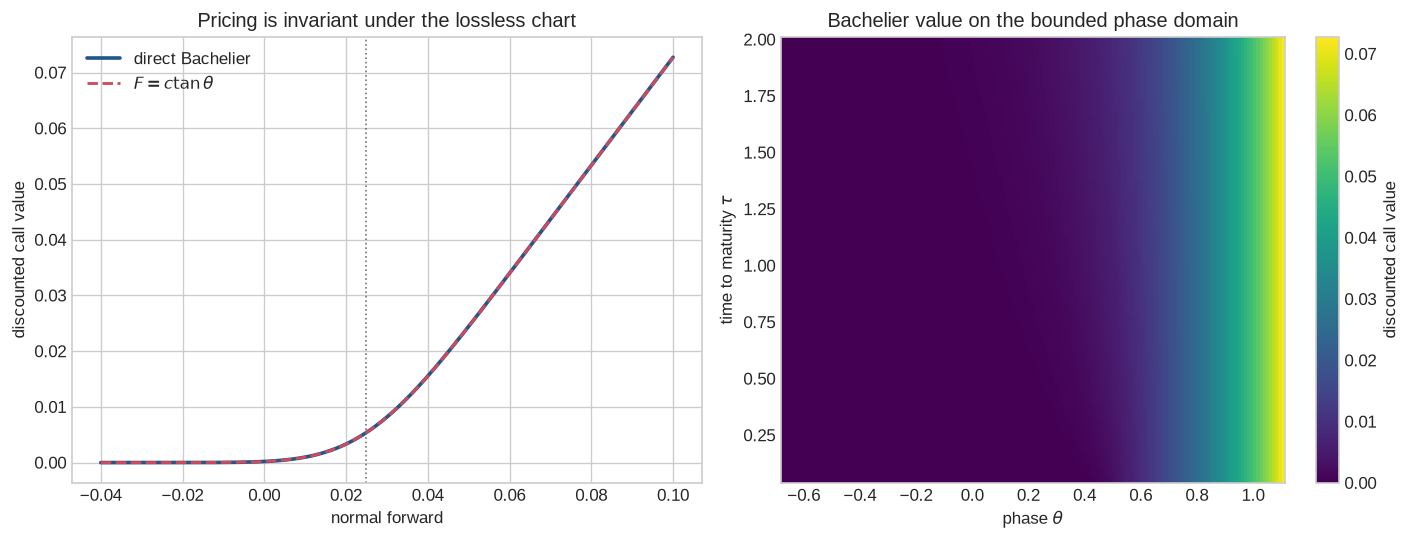

(   forward     theta  direct_price   phase_price  absolute_difference
 0   -0.025 -0.463648  5.803922e-07  5.803922e-07         0.000000e+00
 1    0.000  0.000000  1.990178e-04  1.990178e-04         0.000000e+00
 2    0.025  0.463648  5.408126e-03  5.408126e-03         1.734723e-18
 3    0.050  0.785398  2.444902e-02  2.444902e-02         1.040834e-17
 4    0.085  1.039072  5.820003e-02  5.820003e-02         6.938894e-18,
 {'discount': 0.97,
  'maturity': 1.25,
  'normal_volatility': 0.0125,
  'phase_interval': [-1.5707963267948966, 1.5707963267948966],
  'scale': 0.05,
  'strike': 0.025,
  'grid_points': 401,
  'max_absolute_price_difference': 2.7755575615628914e-17,
  'max_relative_price_difference_above_1e-12': 7.244968103430339e-14})

In [19]:
pricing_scale = 0.05
pricing_strike = 0.025
pricing_volatility = 0.0125
pricing_discount = 0.97
pricing_maturity = 1.25
forward_grid = np.linspace(-0.04, 0.10, 401)
pricing_theta = canonical_phase(forward_grid, pricing_scale)

direct_prices = np.array(
    [
        bachelier_call_price(
            forward,
            pricing_strike,
            normal_volatility=pricing_volatility,
            maturity=pricing_maturity,
            discount=pricing_discount,
        )
        for forward in forward_grid
    ]
)
phase_prices = np.array(
    [
        phase_bachelier_call_price(
            theta,
            scale=pricing_scale,
            strike=pricing_strike,
            normal_volatility=pricing_volatility,
            maturity=pricing_maturity,
            discount=pricing_discount,
        )
        for theta in pricing_theta
    ]
)

benchmark_forwards = np.array(
    [-0.025, 0.0, pricing_strike, 0.05, 0.085]
)
benchmark_rows = []
for forward in benchmark_forwards:
    theta = float(canonical_phase(forward, pricing_scale))
    direct_value = bachelier_call_price(
        forward,
        pricing_strike,
        normal_volatility=pricing_volatility,
        maturity=pricing_maturity,
        discount=pricing_discount,
    )
    phase_value = phase_bachelier_call_price(
        theta,
        scale=pricing_scale,
        strike=pricing_strike,
        normal_volatility=pricing_volatility,
        maturity=pricing_maturity,
        discount=pricing_discount,
    )
    benchmark_rows.append(
        {
            "forward": forward,
            "theta": theta,
            "direct_price": direct_value,
            "phase_price": phase_value,
            "absolute_difference": abs(direct_value - phase_value),
        }
    )
bachelier_benchmarks = save_table(
    pd.DataFrame(benchmark_rows),
    "bachelier_benchmarks.csv",
)

maturity_grid = np.linspace(0.05, 2.0, 90)
surface_theta = np.linspace(
    float(canonical_phase(-0.04, pricing_scale)),
    float(canonical_phase(0.10, pricing_scale)),
    160,
)
price_surface = np.empty((maturity_grid.size, surface_theta.size))
for maturity_index, maturity in enumerate(maturity_grid):
    for theta_index, theta in enumerate(surface_theta):
        price_surface[maturity_index, theta_index] = (
            phase_bachelier_call_price(
                theta,
                scale=pricing_scale,
                strike=pricing_strike,
                normal_volatility=pricing_volatility,
                maturity=maturity,
                discount=pricing_discount,
            )
        )

pricing_conjugacy = save_json(
    {
        "discount": pricing_discount,
        "maturity": pricing_maturity,
        "normal_volatility": pricing_volatility,
        "phase_interval": [-np.pi / 2.0, np.pi / 2.0],
        "scale": pricing_scale,
        "strike": pricing_strike,
        "grid_points": int(forward_grid.size),
        "max_absolute_price_difference": float(
            np.max(np.abs(direct_prices - phase_prices))
        ),
        "max_relative_price_difference_above_1e-12": float(
            np.max(
                np.abs(direct_prices - phase_prices)
                / np.maximum(np.abs(direct_prices), 1e-12)
            )
        ),
    },
    "pricing_conjugacy.json",
)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
axes[0].plot(
    forward_grid,
    direct_prices,
    color="#235789",
    lw=2.2,
    label="direct Bachelier",
)
axes[0].plot(
    forward_grid,
    phase_prices,
    "--",
    color="#d1495b",
    lw=1.7,
    label=r"$F=c\tan\theta$",
)
axes[0].axvline(pricing_strike, color="0.45", ls=":", lw=1)
axes[0].set_xlabel("normal forward")
axes[0].set_ylabel("discounted call value")
axes[0].set_title("Pricing is invariant under the lossless chart")
axes[0].legend()

surface = axes[1].pcolormesh(
    surface_theta,
    maturity_grid,
    price_surface,
    shading="auto",
    cmap="viridis",
)
axes[1].set_xlabel(r"phase $\theta$")
axes[1].set_ylabel(r"time to maturity $\tau$")
axes[1].set_title("Bachelier value on the bounded phase domain")
fig.colorbar(surface, ax=axes[1], label="discounted call value")
save_figure(fig, "f19_bachelier_coordinate_pricing")
bachelier_benchmarks, pricing_conjugacy

## 20. Delta and gamma under the chart

Let (V(x)=v((x))), where (x=c). Then

\[ V_x=v\_, V\_{xx} = . \]

This is ordinary chain-rule conjugacy, including the Hessian correction. To avoid verifying a formula with itself, the phase derivatives below are obtained by central differences of the phase price and compared with independent analytic Bachelier Greeks.

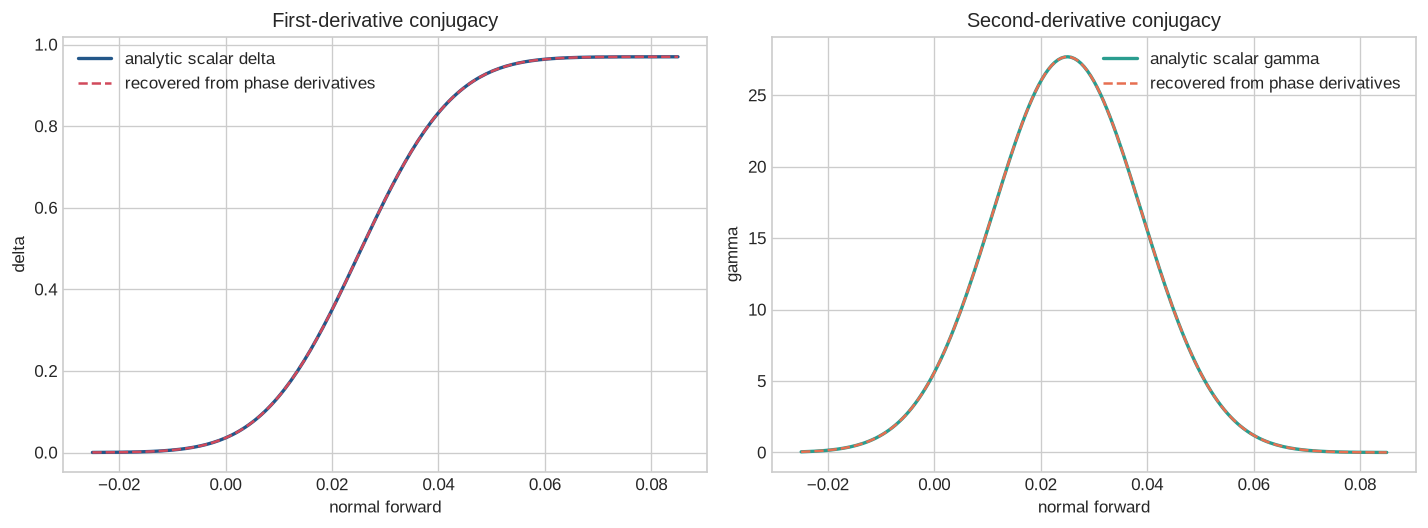

(      forward     theta  analytic_delta  recovered_delta  \
 0   -0.025000 -0.463648        0.000168         0.000168   
 1   -0.024389 -0.453822        0.000199         0.000199   
 2   -0.023778 -0.443902        0.000234         0.000234   
 3   -0.023167 -0.433886        0.000275         0.000275   
 4   -0.022556 -0.423778        0.000323         0.000323   
 ..        ...       ...             ...              ...   
 176  0.082556  1.026231        0.969981         0.969982   
 177  0.083167  1.029493        0.969985         0.969985   
 178  0.083778  1.032721        0.969987         0.969987   
 179  0.084389  1.035913        0.969990         0.969990   
 180  0.085000  1.039072        0.969991         0.969991   
 
      delta_absolute_error  analytic_gamma  recovered_gamma  \
 0            3.557181e-11        0.046008         0.046008   
 1            4.013528e-11        0.053748         0.053748   
 2            4.563951e-11        0.062670         0.062670   
 3            

In [20]:
greek_forward = np.linspace(-0.025, 0.085, 181)
greek_theta = canonical_phase(greek_forward, pricing_scale)
greek_step = 7.5e-5

analytic_delta = np.array(
    [
        bachelier_call_delta(
            forward,
            pricing_strike,
            normal_volatility=pricing_volatility,
            maturity=pricing_maturity,
            discount=pricing_discount,
        )
        for forward in greek_forward
    ]
)
analytic_gamma = np.array(
    [
        bachelier_call_gamma(
            forward,
            pricing_strike,
            normal_volatility=pricing_volatility,
            maturity=pricing_maturity,
            discount=pricing_discount,
        )
        for forward in greek_forward
    ]
)

def phase_price_array(
    theta_values,
    maturity=pricing_maturity,
    discount=pricing_discount,
):
    return np.array(
        [
            phase_bachelier_call_price(
                theta,
                scale=pricing_scale,
                strike=pricing_strike,
                normal_volatility=pricing_volatility,
                maturity=maturity,
                discount=discount,
            )
            for theta in np.asarray(theta_values)
        ]
    )

central_phase_price = phase_price_array(greek_theta)
plus_phase_price = phase_price_array(greek_theta + greek_step)
minus_phase_price = phase_price_array(greek_theta - greek_step)
finite_phase_first = (
    plus_phase_price - minus_phase_price
) / (2.0 * greek_step)
finite_phase_second = (
    plus_phase_price
    - 2.0 * central_phase_price
    + minus_phase_price
) / greek_step**2

recovered_delta = np.array(
    [
        scalar_delta_from_phase(
            float(theta),
            scale=pricing_scale,
            phase_first=float(first),
        )
        for theta, first in zip(greek_theta, finite_phase_first)
    ]
)
recovered_gamma = np.array(
    [
        scalar_gamma_from_phase(
            float(theta),
            scale=pricing_scale,
            phase_first=float(first),
            phase_second=float(second),
        )
        for theta, first, second in zip(
            greek_theta,
            finite_phase_first,
            finite_phase_second,
        )
    ]
)

greek_conjugacy = save_table(
    pd.DataFrame(
        {
            "forward": greek_forward,
            "theta": greek_theta,
            "analytic_delta": analytic_delta,
            "recovered_delta": recovered_delta,
            "delta_absolute_error": np.abs(
                analytic_delta - recovered_delta
            ),
            "analytic_gamma": analytic_gamma,
            "recovered_gamma": recovered_gamma,
            "gamma_absolute_error": np.abs(
                analytic_gamma - recovered_gamma
            ),
        }
    ),
    "greek_conjugacy.csv",
)
greek_summary = save_json(
    {
        "central_difference_step": greek_step,
        "max_delta_absolute_error": float(
            greek_conjugacy["delta_absolute_error"].max()
        ),
        "rms_delta_absolute_error": float(
            np.sqrt(
                np.mean(greek_conjugacy["delta_absolute_error"] ** 2)
            )
        ),
        "max_gamma_absolute_error": float(
            greek_conjugacy["gamma_absolute_error"].max()
        ),
        "rms_gamma_absolute_error": float(
            np.sqrt(
                np.mean(greek_conjugacy["gamma_absolute_error"] ** 2)
            )
        ),
    },
    "greek_conjugacy.json",
)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.5))
axes[0].plot(
    greek_forward,
    analytic_delta,
    color="#235789",
    lw=2,
    label="analytic scalar delta",
)
axes[0].plot(
    greek_forward,
    recovered_delta,
    "--",
    color="#d1495b",
    label="recovered from phase derivatives",
)
axes[0].set_xlabel("normal forward")
axes[0].set_ylabel("delta")
axes[0].set_title("First-derivative conjugacy")
axes[0].legend()

axes[1].plot(
    greek_forward,
    analytic_gamma,
    color="#2a9d8f",
    lw=2,
    label="analytic scalar gamma",
)
axes[1].plot(
    greek_forward,
    recovered_gamma,
    "--",
    color="#e76f51",
    label="recovered from phase derivatives",
)
axes[1].set_xlabel("normal forward")
axes[1].set_ylabel("gamma")
axes[1].set_title("Second-derivative conjugacy")
axes[1].legend()
save_figure(fig, "f20_greek_conjugacy")
greek_conjugacy, greek_summary

## 21. Pricing-PDE generator conjugacy

Under the driftless normal forward model (dF_t=\_N,dW_t), the Bachelier value satisfies

\[ V\_=*N^2 V*{FF}. \]

In the phase chart, the same equation is

\[ v\_=A()v\_ +12B()^2v\_{}, \]

where (A=-(\_N<sup>2/c</sup>2)^3) and (B=(\_N/c)^2). Both sides are approximated independently by centered differences below.

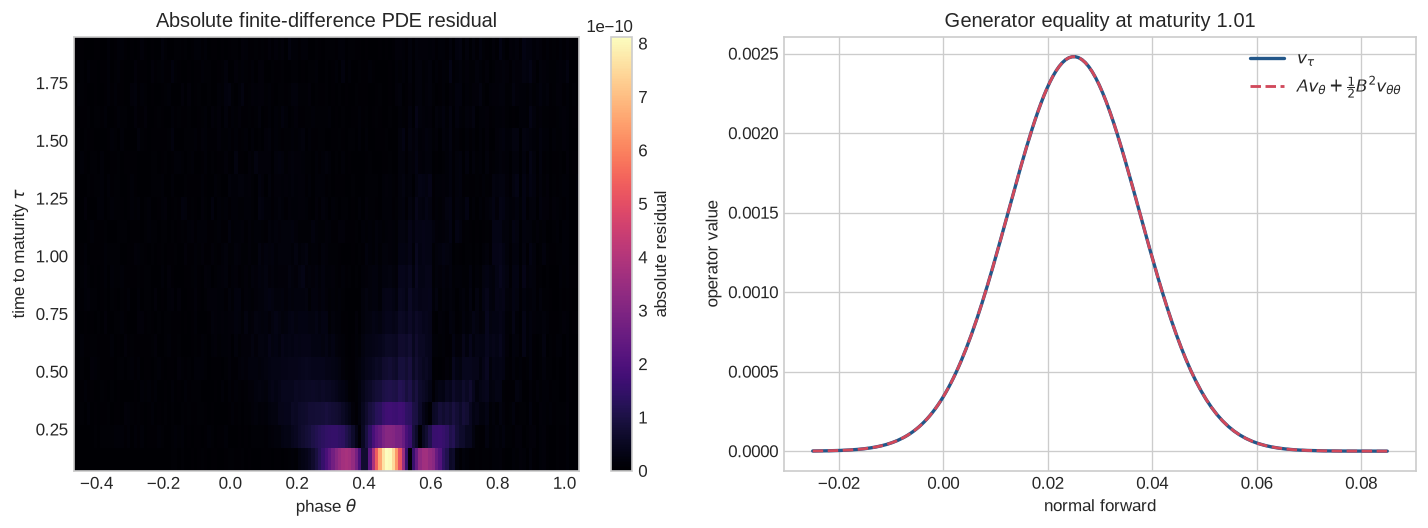

(      maturity     theta   forward  time_derivative  phase_generator  \
 0         0.12 -0.463648 -0.025000     1.077533e-29     1.061474e-29   
 1         0.12 -0.453629 -0.024377     5.478630e-29     5.394926e-29   
 2         0.12 -0.443611 -0.023760     2.685680e-28     2.643613e-28   
 3         0.12 -0.433593 -0.023149     1.270773e-27     1.250366e-27   
 4         0.12 -0.423575 -0.022543     5.810095e-27     5.714426e-27   
 ...        ...       ...       ...              ...              ...   
 2864      1.90  0.999000  0.077699     1.682808e-05     1.682809e-05   
 2865      1.90  1.009018  0.079437     1.229888e-05     1.229890e-05   
 2866      1.90  1.019036  0.081231     8.803560e-06     8.803564e-06   
 2867      1.90  1.029054  0.083084     6.161723e-06     6.161724e-06   
 2868      1.90  1.039072  0.085000     4.209371e-06     4.209367e-06   
 
           residual  
 0     1.605951e-31  
 1     8.370405e-31  
 2     4.206609e-30  
 3     2.040719e-29  
 4     9.566

In [21]:
pde_theta = np.linspace(
    float(canonical_phase(-0.025, pricing_scale)),
    float(canonical_phase(0.085, pricing_scale)),
    151,
)
pde_maturities = np.linspace(0.12, 1.90, 19)
pde_theta_step = 8.0e-5
pde_time_step = 2.5e-5
pde_rows_finance = []

for maturity in pde_maturities:
    value_center = phase_price_array(
        pde_theta,
        maturity=maturity,
        discount=1.0,
    )
    value_theta_plus = phase_price_array(
        pde_theta + pde_theta_step,
        maturity=maturity,
        discount=1.0,
    )
    value_theta_minus = phase_price_array(
        pde_theta - pde_theta_step,
        maturity=maturity,
        discount=1.0,
    )
    value_time_plus = phase_price_array(
        pde_theta,
        maturity=maturity + pde_time_step,
        discount=1.0,
    )
    value_time_minus = phase_price_array(
        pde_theta,
        maturity=maturity - pde_time_step,
        discount=1.0,
    )
    derivative_time = (
        value_time_plus - value_time_minus
    ) / (2.0 * pde_time_step)
    derivative_theta = (
        value_theta_plus - value_theta_minus
    ) / (2.0 * pde_theta_step)
    derivative_theta_theta = (
        value_theta_plus
        - 2.0 * value_center
        + value_theta_minus
    ) / pde_theta_step**2
    phase_drift, phase_diffusion = canonical_phase_coefficients(
        pde_theta,
        0.0,
        pricing_volatility,
        pricing_scale,
    )
    generator_value = (
        phase_drift * derivative_theta
        + 0.5 * phase_diffusion**2 * derivative_theta_theta
    )
    for theta, left, right in zip(
        pde_theta,
        derivative_time,
        generator_value,
    ):
        pde_rows_finance.append(
            {
                "maturity": maturity,
                "theta": theta,
                "forward": pricing_scale * np.tan(theta),
                "time_derivative": left,
                "phase_generator": right,
                "residual": left - right,
            }
        )

pricing_pde_residual = save_table(
    pd.DataFrame(pde_rows_finance),
    "pricing_pde_residual.csv",
)
pricing_pde_summary = save_json(
    {
        "theta_step": pde_theta_step,
        "time_step": pde_time_step,
        "evaluations": int(len(pricing_pde_residual)),
        "max_absolute_residual": float(
            pricing_pde_residual["residual"].abs().max()
        ),
        "rms_residual": float(
            np.sqrt(
                np.mean(pricing_pde_residual["residual"] ** 2)
            )
        ),
        "max_relative_residual_above_1e-8": float(
            np.max(
                pricing_pde_residual["residual"].abs()
                / np.maximum(
                    pricing_pde_residual["time_derivative"].abs(),
                    1e-8,
                )
            )
        ),
    },
    "pricing_pde_summary.json",
)

residual_matrix = pricing_pde_residual.pivot(
    index="maturity",
    columns="theta",
    values="residual",
)
middle_maturity = pde_maturities[len(pde_maturities) // 2]
middle_slice = pricing_pde_residual[
    np.isclose(
        pricing_pde_residual["maturity"],
        middle_maturity,
    )
]

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.5))
residual_image = axes[0].pcolormesh(
    residual_matrix.columns.to_numpy(),
    residual_matrix.index.to_numpy(),
    np.abs(residual_matrix.to_numpy()),
    shading="auto",
    cmap="magma",
)
axes[0].set_xlabel(r"phase $\theta$")
axes[0].set_ylabel(r"time to maturity $\tau$")
axes[0].set_title("Absolute finite-difference PDE residual")
fig.colorbar(
    residual_image,
    ax=axes[0],
    label="absolute residual",
)

axes[1].plot(
    middle_slice["forward"],
    middle_slice["time_derivative"],
    color="#235789",
    lw=2,
    label=r"$v_\tau$",
)
axes[1].plot(
    middle_slice["forward"],
    middle_slice["phase_generator"],
    "--",
    color="#d1495b",
    lw=1.7,
    label=r"$A v_\theta+\frac{1}{2}B^2v_{\theta\theta}$",
)
axes[1].set_xlabel("normal forward")
axes[1].set_ylabel("operator value")
axes[1].set_title(
    f"Generator equality at maturity {middle_maturity:.2f}"
)
axes[1].legend()
save_figure(fig, "f21_bachelier_pde_conjugacy")
pricing_pde_residual, pricing_pde_summary

## 22. Financial scope controls

Three controls delimit what the coordinate can and cannot do.

1.  A European payoff is identical sample by sample after exact inversion, so the chart alone does not reduce Monte Carlo variance.
2.  Brownian bridges with one common endpoint have different time averages, so terminal phase cannot price path dependence without additional state or the full phase path.
3.  A nonsingular two-factor Gaussian law has covariance rank two and cannot be losslessly compressed into one smooth scalar phase.

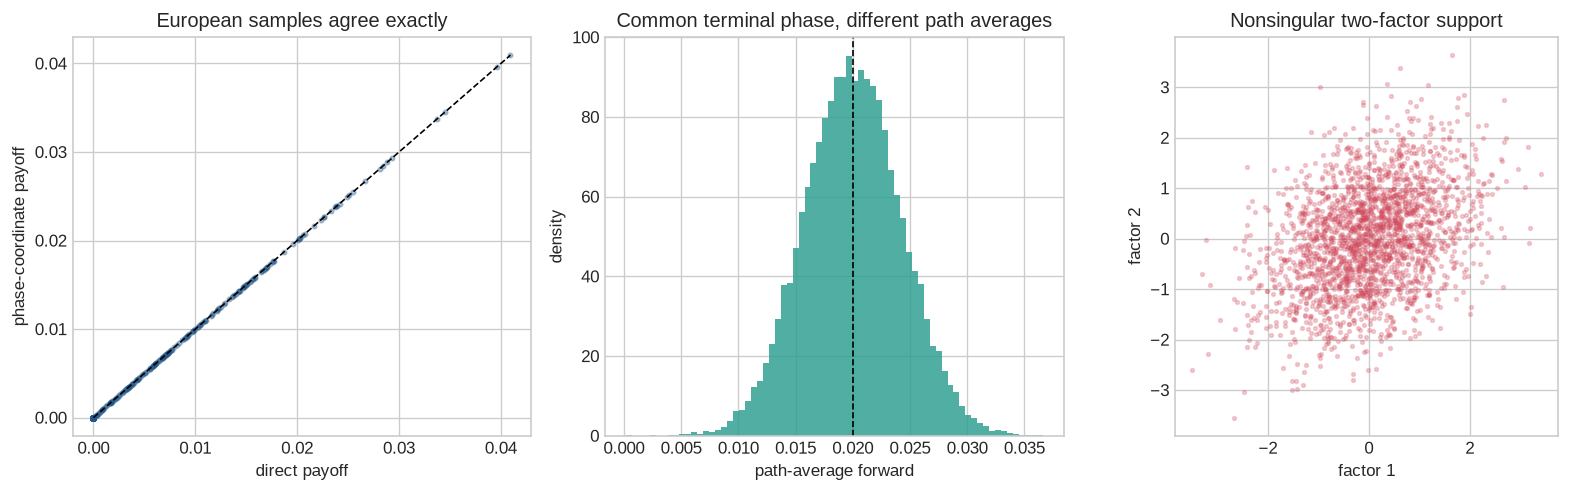

(                            control                              metric  \
 0      European samplewise equality  maximum absolute payoff difference   
 1       European estimator variance  direct minus phase sample variance   
 2           pinned Brownian bridges  standard deviation of path average   
 3           pinned Brownian bridges       maximum terminal phase spread   
 4  two-factor Gaussian terminal law      smallest covariance eigenvalue   
 5  two-factor Gaussian terminal law              covariance determinant   
 
           value                                     interpretation  
 0  1.387779e-17  lossless reparameterization leaves each sample...  
 1  6.776264e-21     the chart alone supplies no variance reduction  
 2  4.267495e-03  one terminal phase does not determine path his...  
 3  2.775558e-16  all bridges share the same endpoint up to roun...  
 4  6.538677e-01  positive second eigenvalue certifies two-dimen...  
 5  8.785631e-01  nonsingular covariance precl

In [22]:
rng_finance = np.random.default_rng(BASE_SEED + 20)

# European payoff: exact samplewise coordinate invariance.
finance_samples = 160_000
finance_horizon = 1.4
finance_forward0 = 0.02
finance_normals = rng_finance.normal(size=finance_samples)
finance_terminal = (
    finance_forward0
    + pricing_volatility
    * np.sqrt(finance_horizon)
    * finance_normals
)
finance_phase = canonical_phase(finance_terminal, pricing_scale)
finance_reconstructed = canonical_inverse(
    finance_phase,
    pricing_scale,
)
european_direct = np.maximum(
    finance_terminal - pricing_strike,
    0.0,
)
european_phase = np.maximum(
    finance_reconstructed - pricing_strike,
    0.0,
)

# Brownian bridges pinned at the same terminal factor.
bridge_paths, bridge_steps = 28_000, 80
bridge_times = np.linspace(
    finance_horizon / bridge_steps,
    finance_horizon,
    bridge_steps,
)
bridge_dw = rng_finance.normal(
    scale=np.sqrt(finance_horizon / bridge_steps),
    size=(bridge_paths, bridge_steps),
)
bridge_w = np.cumsum(bridge_dw, axis=1)
brownian_bridge = (
    bridge_w
    - bridge_times[None, :]
    * bridge_w[:, -1, None]
    / finance_horizon
)
bridge_factor = (
    finance_forward0
    + pricing_volatility * brownian_bridge
)
bridge_average = bridge_factor.mean(axis=1)
bridge_terminal = bridge_factor[:, -1]
bridge_terminal_phase = canonical_phase(
    bridge_terminal,
    pricing_scale,
)

# A genuine two-factor terminal law.
factor_samples = 120_000
correlation = 0.35
independent_normals = rng_finance.normal(
    size=(factor_samples, 2)
)
factor_one = independent_normals[:, 0]
factor_two = (
    correlation * independent_normals[:, 0]
    + np.sqrt(1.0 - correlation**2)
    * independent_normals[:, 1]
)
two_factor = np.column_stack([factor_one, factor_two])
two_factor_covariance = np.cov(two_factor, rowvar=False)
two_factor_eigenvalues = np.linalg.eigvalsh(
    two_factor_covariance
)
save_table(
    pd.DataFrame(
        two_factor_covariance,
        index=["factor_1", "factor_2"],
        columns=["factor_1", "factor_2"],
    ).reset_index(names="row"),
    "two_factor_covariance.csv",
)

financial_scope_controls = save_table(
    pd.DataFrame(
        [
            {
                "control": "European samplewise equality",
                "metric": "maximum absolute payoff difference",
                "value": np.max(
                    np.abs(european_direct - european_phase)
                ),
                "interpretation": "lossless reparameterization leaves each sample unchanged",
            },
            {
                "control": "European estimator variance",
                "metric": "direct minus phase sample variance",
                "value": np.var(european_direct, ddof=1)
                - np.var(european_phase, ddof=1),
                "interpretation": "the chart alone supplies no variance reduction",
            },
            {
                "control": "pinned Brownian bridges",
                "metric": "standard deviation of path average",
                "value": np.std(bridge_average, ddof=1),
                "interpretation": "one terminal phase does not determine path history",
            },
            {
                "control": "pinned Brownian bridges",
                "metric": "maximum terminal phase spread",
                "value": np.ptp(bridge_terminal_phase),
                "interpretation": "all bridges share the same endpoint up to roundoff",
            },
            {
                "control": "two-factor Gaussian terminal law",
                "metric": "smallest covariance eigenvalue",
                "value": two_factor_eigenvalues[0],
                "interpretation": "positive second eigenvalue certifies two-dimensional support",
            },
            {
                "control": "two-factor Gaussian terminal law",
                "metric": "covariance determinant",
                "value": np.linalg.det(two_factor_covariance),
                "interpretation": "nonsingular covariance precludes smooth one-phase compression",
            },
        ]
    ),
    "financial_scope_controls.csv",
)
bridge_summary = save_json(
    {
        "paths": bridge_paths,
        "steps": bridge_steps,
        "common_terminal_forward_max_error": float(
            np.max(
                np.abs(bridge_terminal - finance_forward0)
            )
        ),
        "common_terminal_phase_max_spread": float(
            np.ptp(bridge_terminal_phase)
        ),
        "path_average_standard_deviation": float(
            np.std(bridge_average, ddof=1)
        ),
        "path_average_quantiles": {
            str(probability): float(
                np.quantile(bridge_average, probability)
            )
            for probability in (
                0.01,
                0.10,
                0.50,
                0.90,
                0.99,
            )
        },
    },
    "brownian_bridge_path_control.json",
)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
payoff_subset = slice(None, None, 320)
axes[0].scatter(
    european_direct[payoff_subset],
    european_phase[payoff_subset],
    s=7,
    alpha=0.35,
    color="#235789",
)
payoff_limit = max(
    european_direct[payoff_subset].max(),
    european_phase[payoff_subset].max(),
)
axes[0].plot(
    [0.0, payoff_limit],
    [0.0, payoff_limit],
    "k--",
    lw=1,
)
axes[0].set_xlabel("direct payoff")
axes[0].set_ylabel("phase-coordinate payoff")
axes[0].set_title("European samples agree exactly")

axes[1].hist(
    bridge_average,
    bins=70,
    density=True,
    color="#2a9d8f",
    alpha=0.82,
)
axes[1].axvline(
    finance_forward0,
    color="black",
    ls="--",
    lw=1,
)
axes[1].set_xlabel("path-average forward")
axes[1].set_ylabel("density")
axes[1].set_title(
    "Common terminal phase, different path averages"
)

cloud_subset = slice(None, None, 55)
axes[2].scatter(
    factor_one[cloud_subset],
    factor_two[cloud_subset],
    s=5,
    alpha=0.25,
    color="#d1495b",
)
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_xlabel("factor 1")
axes[2].set_ylabel("factor 2")
axes[2].set_title("Nonsingular two-factor support")
save_figure(fig, "f22_financial_scope_controls")

expected_figure_stems = [
    "f01_secant_geometry",
    "f02_general_affine_geometry",
    "f03_support_obstructions",
    "f04_angle_bin_factorization",
    "f05_phase_sde_convergence",
    "f06_boundary_stress",
    "f07_transition_diagnostics",
    "f08_generator_and_endpoint_checks",
    "f09_cayley_compactification",
    "f10_transported_group",
    "f11_additive_vs_spiral",
    "f12_rigidity_families",
    "f13_moving_line_fallback",
    "f14_vector_geometry_and_controls",
    "f15_complex_derivative_limits",
    "f16_pde_compactification",
    "f17_monte_carlo_equivalence",
    "f18_evidence_decisions",
    "f19_bachelier_coordinate_pricing",
    "f20_greek_conjugacy",
    "f21_bachelier_pde_conjugacy",
    "f22_financial_scope_controls",
]
figure_manifest_rows = []
for stem in expected_figure_stems:
    for format_name, directory, suffix in [
        ("raster", RASTER, ".png"),
        ("vector", VECTOR, ".pdf"),
    ]:
        path = directory / f"{stem}{suffix}"
        figure_manifest_rows.append(
            {
                "stem": stem,
                "format": format_name,
                "relative_path": str(path.relative_to(PAPER)),
                "exists": path.exists(),
                "bytes": (
                    path.stat().st_size
                    if path.exists()
                    else 0
                ),
            }
        )
figure_manifest = save_table(
    pd.DataFrame(figure_manifest_rows),
    "figure_manifest.csv",
)

notebook_summary = save_json(
    {
        "expected_figures_per_format": len(
            expected_figure_stems
        ),
        "missing_figure_files": int(
            (~figure_manifest["exists"]).sum()
        ),
        "minimum_figure_bytes": int(
            figure_manifest["bytes"].min()
        ),
        "max_pricing_conjugacy_error": pricing_conjugacy[
            "max_absolute_price_difference"
        ],
        "max_delta_error": greek_summary[
            "max_delta_absolute_error"
        ],
        "max_gamma_error": greek_summary[
            "max_gamma_absolute_error"
        ],
        "max_pricing_pde_residual": pricing_pde_summary[
            "max_absolute_residual"
        ],
        "bridge_path_average_standard_deviation": (
            bridge_summary[
                "path_average_standard_deviation"
            ]
        ),
        "two_factor_covariance_rank": int(
            np.linalg.matrix_rank(
                two_factor_covariance,
                tol=1e-8,
            )
        ),
    },
    "notebook_summary.json",
)

assert figure_manifest["exists"].all()
assert (figure_manifest["bytes"] > 1_000).all()
assert (
    pricing_conjugacy["max_absolute_price_difference"]
    < 1e-14
)
assert greek_summary["max_delta_absolute_error"] < 2e-6
assert greek_summary["max_gamma_absolute_error"] < 2e-3
assert (
    pricing_pde_summary["max_absolute_residual"]
    < 2e-4
)
assert (
    bridge_summary["path_average_standard_deviation"]
    > 1e-3
)
assert (
    np.linalg.matrix_rank(
        two_factor_covariance,
        tol=1e-8,
    )
    == 2
)

(
    financial_scope_controls,
    bridge_summary,
    figure_manifest,
    notebook_summary,
)

## 23. Final computational conclusion

The shortest correct additive formula is

\[ \]

for the canonical complex lift (Z_t=Z_0\[1+i(t+W_t)/c\]). Equivalently, the phase may be defined by its autonomous SDE, generator, or exact transition kernel, so the state formula needs no separate (t,W_t) coordinates.

The phase is a bounded chart on a line, not an unrestricted rotation. If winding is essential, the compatible multiplicative logarithmic spiral is the exact alternative:

\[ \]

That second formula changes the stochastic model. Neither coordinate identity changes the meaning of quadratic variation or supplies a universal replacement for Itô calculus.